# 0B · Maths du lycée au ML — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch00b_maths/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 0B.1 à 0B.27 | vérifier tes exercices papier ✏️ | ✏️ | ★ à ★★ | |
| A | 0B.33 | Calculer avec Python : puissances, arrondis, `abs`, signe et `C(n, k)` | 📦 | ★ | 10 |
|  | 0B.34 | 0,99 puissance 1000 : presque 1 ou presque 0 ? | 🔮 | ★ | 10 |
|  | 0B.35 | Σ, Π et moyennes en code : `sum`, `math.prod`, `np.average`, moyenne mobile | 📦 | ★★ | 15 |
|  | 0B.36 | Galerie des fonctions usuelles : de l'affine au cosinus | 📦 | ★★ | 20 |
|  | 0B.37 | `exp` et `log` en NumPy : `-inf`, `nan` et dépassements | 🐛 | ★★ | 15 |
| B | 0B.38 | `linalg_basics` (1) : additionner, soustraire, multiplier des vecteurs | 🔨 | ★★ | 15 |
|  | 0B.39 | `linalg_basics` (2) : produit scalaire, norme, distance, cosinus | 🔨 | ★★ | 20 |
|  | 0B.40 | Tes fonctions contre NumPy : mêmes résultats, autre vitesse | 📦 | ★★ | 15 |
|  | 0B.41 | Distance ou similarité cosinus : l'effet de la longueur | 🔬 | ★★ | 20 |
|  | 0B.42 | `linalg_basics` (3) : forme, transposée, identité, matrice × vecteur | 🔨 | ★★ | 20 |
|  | 0B.43 | `linalg_basics` (4) : `matmul` et vérification des formes | 🔨 | ★★ | 25 |
|  | 0B.44 | AB = BA ? (AB)ᵀ = BᵀAᵀ ? Prédire, puis tester | 🔮 | ★★ | 15 |
|  | 0B.45 | Le produit qui n'en est pas un : `*`, `@`, `(n,)` et `(n, 1)` | 🐛 | ★★ | 20 |
|  | 0B.46 | Inverse et systèmes : `np.linalg.inv` et `np.linalg.solve` | 📦 | ★★ | 15 |
| C | 0B.47 | Pentes numériques : vérifier tes dérivées à la main | 🔨 | ★★ | 20 |
|  | 0B.48 | Lire les variations : f, f′ et les points où f′ s'annule | 📈 | ★★ | 15 |
|  | 0B.49 | Carte de lignes de niveau et flèches du gradient | 📈 | ★★ | 20 |
|  | 0B.50 | Contre le gradient, avec lui ou le long d'une ligne de niveau : où va f ? | 🔮 | ★★ | 15 |
|  | 0B.51 | Dérivées partielles numériques et somme sur les chemins | 🔨 | ★★ | 25 |
| D | 0B.52 | Simuler des dés : fréquences, indépendance, loi des grands nombres | 🔬 | ★★ | 25 |
|  | 0B.53 | Espérance et variance : le calcul exact contre la simulation | 🔨 | ★★ | 20 |
|  | 0B.54 | L'ordre des produits : calculer A·B·C·v des dizaines de fois plus vite | 🏆 | ★★★ | 40 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Vérifier tes calculs à la main (partie 0), puis les retrouver en code.
- Écrire l'algèbre linéaire en Python pur (`mylearn.linalg_basics`) et la comparer à NumPy.
- Estimer des dérivées et des gradients par des pentes numériques, et lire des lignes de niveau.
- Confirmer des probabilités, des espérances et des variances par simulation.

**Rappel express.** $\sum$ est une boucle ; $(m, n) \times (n, p) \to (m, p)$ ; $\frac{dz}{dx} = \frac{dz}{dy}\frac{dy}{dx}$ ; on descend en soustrayant le gradient ; en code, `np.log` est $\ln$ et `A @ B` est le produit matriciel (`A * B` est élément par élément).

## Partie 0 · Vérifier tes exercices papier (✏️ de 0B.1 à 0B.27)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125`, `[7, -2]`, `[[1, 0], [0, 1]]`, `(4, 5)`, `True`), pas l'expression Python, sinon tu ne vérifies rien. Arrondis comme l'énoncé le demande. Les réponses pas encore remplies affichent ⏳.

In [2]:
# Data of the paper exercises (the same as in 02_exercices.md)
import math
from itertools import product

import numpy as np

x3 = [2, -1, 4, 3]                                                   # 0B.3
s4 = [2, 4, 9, 1, 5, 6]                                              # 0B.4
omega5 = set(range(1, 13))                                           # 0B.5
A5 = {n for n in omega5 if n % 2 == 0}
B5 = {n for n in omega5 if n % 3 == 0}
C5 = {1, 2, 3}
p1, p2, u8 = np.array([40, 190]), np.array([48, 196]), np.array([3, -4])   # 0B.8
A9 = np.array([[2, 0, 1], [-1, 3, 2]])                               # 0B.9
v9 = np.array([1, 2, -1])
X9 = np.array([[1, 2], [3, 0], [0, -1]])
w9 = np.array([0.5, 2])


def f10(x):                                                          # 0B.10
    return x ** 2 + x


DICE = list(product(range(1, 7), repeat=2))                         # 0B.11, 0B.26


def prob(event):
    """Probability of an event (a function of the pair of dice) with two fair dice."""
    return sum(1 for d in DICE if event(d)) / len(DICE)


def first_even(d):
    return d[0] % 2 == 0


def sum_is(total):
    return lambda d: d[0] + d[1] == total


def sigmoid(x):                                                      # 0B.17
    return 1 / (1 + math.exp(-x))


va, vb, vc, vd = (np.array(v) for v in ([1, 2, 2], [2, 0, -1], [2, 4, 4], [1, 0, 0]))   # 0B.18


def cosine(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))


A20 = np.array([[1, 2], [0, -1], [3, 1]])                            # 0B.20
B20 = np.array([[2, 1, 0], [1, -1, 4]])
C20 = np.array([[1, 1], [2, 0]])
M21 = np.array([[3.0, 1.0], [4.0, 2.0]])                             # 0B.21


def f25(x, y):                                                       # 0B.25
    return (x - 1) ** 2 + 2 * y ** 2


values27, probs27 = np.array([0, 1, 2, 5]), np.array([0.4, 0.3, 0.2, 0.1])   # 0B.27

**Ex 0B.1 — Puissances, racines et notation scientifique sans calculatrice**

In [3]:
wb.record("0B.1a", 2 ** 5 * 2 ** 3, mistakes={"on ADDITIONNE les exposants : 2^(5+3)": 2 ** 15})
wb.record("0B.1b", (10 ** 2) ** 3 / 10 ** 4, decimals=0, mistakes={"(10^2)^3 = 10^6 : on MULTIPLIE les exposants": 10})
wb.record("0B.1c", 5 ** -2, decimals=2, mistakes={"un exposant négatif donne un inverse, pas un nombre négatif": -25})
wb.record("0B.1d", math.sqrt(49 * 16), decimals=0)
wb.record("0B.1e", round(8 ** (2 / 3)), mistakes={"8^(1/3) = 2 (racine cubique), puis 2^2": 2})
wb.record("0B.1f", 3.2e5 * 2e-3, decimals=0)
wb.record("0B.1g", math.floor(math.log10(0.00056)), mistakes={"pour un nombre plus petit que 1, l'exposant est négatif": 4})
wb.record("0B.1h", round(30 * math.log10(2)), mistakes={"on cherche l'exposant de 10, pas celui de 2 : 2^30 = (2^10)^3 et 2^10 ≈ 10^3": 30})

WB_ANSWER {"hash": "0d51f482a1d5a7103acd9e4cc820fdd77581c864d6419aa16beec4df8b3e62af", "id": "0B.1a", "kind": "int", "magnitude": 2, "mistakes": {"f5ba6170bce85fea52e2c8e53fc634efb5d222b1c67fad029c1e8a0decd1c5ff": "on ADDITIONNE les exposants : 2^(5+3)"}, "sign": 1}
📝 Ex 0B.1a : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "hash": "5da56270075d9f428261749bbd4c46d4f5cb82cfecae7a15bca6745155e0870a", "id": "0B.1b", "kind": "float", "magnitude": 2, "mistakes": {"a793cee87d221a442fe3cbf5bdc4940ce8a4b93c501584d44594460e69f93d03": "(10^2)^3 = 10^6 : on MULTIPLIE les exposants"}, "sign": 1}
📝 Ex 0B.1b : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "1560abe06013657987b528d83b6fd798824a7d69aedce4a27c8d28b934766523", "hash_coarse": "180f69baafd380dd89c0dbc86a44d0a90214f8d579b92ec21bc8791b0417baeb", "id": "0B.1c", "kind": "float", "magnitude": -2, "mistakes": {"d46ee241d38924195d39c03906dc4c5fe8acd6e47e00550a053374e139d12e30": "un exposant négatif donne un 

**Ex 0B.2 — Valeur absolue, partie entière et signe : tableau de valeurs**

In [4]:
wb.record("0B.2a", abs(-7) + abs(3 - 5), mistakes={"une valeur absolue est toujours positive : |3 − 5| = 2": 5})
wb.record("0B.2b", math.floor(3.7))
wb.record("0B.2c", math.floor(-3.7), mistakes={"le plancher va vers le BAS (vers −∞) : prends l'entier juste en dessous de −3,7": -3})
wb.record("0B.2d", math.ceil(-3.7), mistakes={"le plafond va vers le HAUT : prends l'entier juste au-dessus de −3,7": -4})
wb.record("0B.2e", math.ceil(2.01))
wb.record("0B.2f", int(np.sign(-0.5) + np.sign(0) + np.sign(12)), mistakes={"sign(0) vaut 0": 1})
wb.record("0B.2g", 4 - 1.5, decimals=1)
wb.record("0B.2h", 4 + 1.5, decimals=1)
wb.record("0B.2i", sum(1 for x in range(-10, 11) if abs(x) < 3), mistakes={"inégalité stricte : 3 et −3 sont exclus": 7, "les entiers négatifs comptent aussi": 3})

WB_ANSWER {"hash": "7a61f56c4ac9fd30230d07c53b7c4a0c33db86570df56b379ada4c250c993075", "id": "0B.2a", "kind": "int", "magnitude": 0, "mistakes": {"7d542dfb3b7258987a6c2d11ced875501f7bf1d9cd3ee05c0fff1d3b61a2c751": "une valeur absolue est toujours positive : |3 − 5| = 2"}, "sign": 1}
📝 Ex 0B.2a : réponse enregistrée (int).
WB_ANSWER {"hash": "40f8108fa1f6e3f6dc1549005533c81e2d67ef053ef14795d2069024c069a9af", "id": "0B.2b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 0B.2b : réponse enregistrée (int).
WB_ANSWER {"hash": "5d6ae8b95d0ef081078e8c3321a2656e761843688d063f65d720b5fc36b3881a", "id": "0B.2c", "kind": "int", "magnitude": 0, "mistakes": {"4937808cfb3fed9e204b51cd7e320bad62e47369c8ca5e4498540b0f764545a4": "le plancher va vers le BAS (vers −∞) : prends l'entier juste en dessous de −3,7"}, "sign": -1}
📝 Ex 0B.2c : réponse enregistrée (int).
WB_ANSWER {"hash": "30728b838032d176bd1d934a6cfc94c0408aebfc125fc111e9d8ab86465b823f", "id": "0B.2d", "kind": "int", "magnitude": 0, "mistakes

**Ex 0B.3 — Lire et calculer des Σ et des Π**

In [5]:
wb.record("0B.3a", sum(range(1, 6)))
wb.record("0B.3b", sum(2 * i - 1 for i in range(1, 5)))
wb.record("0B.3c", sum(3 ** k for k in range(4)), mistakes={"k commence à 0 : le terme 3^0 = 1 compte aussi": 39})
wb.record("0B.3d", math.prod(i + 1 for i in range(1, 5)))
wb.record("0B.3e", sum(v ** 2 for v in x3), mistakes={"le carré de −1 vaut +1": 28})
wb.record("0B.3f", sum(3 * v + 1 for v in x3), mistakes={"le +1 est ajouté à chacun des 4 termes, pas une seule fois": 25})
wb.record("0B.3g", 5 * 100)
wb.record("0B.3h", sum(i * x3[i - 1] for i in range(2, 5)), mistakes={"la somme commence à i = 2 : le terme 1 × x_1 n'y est pas": 24})

WB_ANSWER {"hash": "9b434400e82cf32bd26f6ff3bd47cca8cb65a99a10088c916696720e4c10d627", "id": "0B.3a", "kind": "int", "magnitude": 1, "sign": 1}
📝 Ex 0B.3a : réponse enregistrée (int).
WB_ANSWER {"hash": "ebbc7b814ebfc4db0b864b0585d32bf195417aa719d12c78339365c08470196d", "id": "0B.3b", "kind": "int", "magnitude": 1, "sign": 1}
📝 Ex 0B.3b : réponse enregistrée (int).
WB_ANSWER {"hash": "b78004d6d0eff20a0d1ffa2c4f55bc036c0c6309e986167a5df3f483d5fdc46a", "id": "0B.3c", "kind": "int", "magnitude": 1, "mistakes": {"e26efcab5b5e9e47f7b1b9d34cedd6800451bb841487d9c24e5a2230dc14f990": "k commence à 0 : le terme 3^0 = 1 compte aussi"}, "sign": 1}
📝 Ex 0B.3c : réponse enregistrée (int).
WB_ANSWER {"hash": "7fc5913a13319c28f72714520e18b35ca0af929ddd05c556fc195c3afb530285", "id": "0B.3d", "kind": "int", "magnitude": 2, "sign": 1}
📝 Ex 0B.3d : réponse enregistrée (int).
WB_ANSWER {"hash": "f749103a27f1ac3ffe68acfd8af074b7e0758882267479121ebb96d2337f3e3c", "id": "0B.3e", "kind": "int", "magnitude": 1,

**Ex 0B.4 — Moyenne pondérée, somme pondérée et moyenne mobile à la main**

In [6]:
wb.record("0B.4a", np.mean([4, 8, 6, 10, 2]), decimals=0)
wb.record("0B.4b", np.average([14, 8, 11], weights=[3, 1, 2]), decimals=0, mistakes={"divise par la somme des coefficients (6), pas par le nombre de notes": 24})
wb.record("0B.4c", 0.2 * 10 - 0.5 * 4 + 1 * 3 - 1, decimals=1, mistakes={"n'oublie pas le biais b = −1": 3})
wb.record("0B.4d", [round(np.mean(s4[t - 3:t]), 2) for t in range(3, 7)], decimals=2)
wb.record("0B.4e", 50 - 7 + 1, mistakes={"la première moyenne mobile existe à t = k : il y a n − k + 1 valeurs": 43})

WB_ANSWER {"decimals": 0, "hash": "828a5bed7d1429bd7f1edd596fca0f85cfb197a12bfb700a8b357715d861f482", "id": "0B.4a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.4a : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "hash": "cfbd96e25aac9967155a4f74553420ce0041952ef4062ae722e00efcb7adc661", "id": "0B.4b", "kind": "float", "magnitude": 1, "mistakes": {"177287f1d313cdfb4f7ef0f4144b69364646849dcb9f297311de60583769be01": "divise par la somme des coefficients (6), pas par le nombre de notes"}, "sign": 1}
📝 Ex 0B.4b : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "e92823d2ffb79457eb255fe66e7cdff8f9940757ee614bc8bc653ce6b3a4acad", "hash_coarse": "171052ea36c3485b17bf912322758967bb698e00658cd1286612bd34cbaba626", "id": "0B.4c", "kind": "float", "magnitude": 0, "mistakes": {"f0d493d3b55c4b7358efc19e76557f35e028da7c50e0504e988333cb281c60c7": "n'oublie pas le biais b = −1"}, "sign": 1}
📝 Ex 0B.4c : réponse enregistrée (float, 1 décimale(

**Ex 0B.5 — Ensembles : union, intersection, complémentaire et cardinal**

In [7]:
wb.record("0B.5a", len(A5 & B5))
wb.record("0B.5b", len(A5 | B5), mistakes={"retire l'intersection, comptée deux fois": 10})
wb.record("0B.5c", len(omega5 - A5))
wb.record("0B.5d", len((omega5 - A5) & (omega5 - B5)), mistakes={"ni multiple de 2 NI multiple de 3 : c'est le complémentaire de A ∪ B": 8, "« ni… ni… » exclut aussi les nombres qui ne sont que dans A, ou que dans B": 10})
wb.record("0B.5e", A5 & C5, ordered=False)
wb.record("0B.5f", len(A5 | B5 | C5), mistakes={"2 et 3 sont déjà dans A ∪ B : seul 1 est nouveau": 11})

WB_ANSWER {"hash": "1281fee28000528462fc0f6ca3c31aa2c319d0512ccc28565dbc92750123c641", "id": "0B.5a", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 0B.5a : réponse enregistrée (int).
WB_ANSWER {"hash": "bfe46db0c4d40f5b8d1fd8350d4c82a3d4eb48331d5430465e29f5c6f6ab23bf", "id": "0B.5b", "kind": "int", "magnitude": 0, "mistakes": {"8a85f989066221c550977e78c42df41b94af10eea5477a17fadedb8073b10a8f": "retire l'intersection, comptée deux fois"}, "sign": 1}
📝 Ex 0B.5b : réponse enregistrée (int).
WB_ANSWER {"hash": "4c076e622fc2c36d84b5a0af3796328a2a328e87eea5536e1889a247767b165c", "id": "0B.5c", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 0B.5c : réponse enregistrée (int).
WB_ANSWER {"hash": "fb5b4835f33cd71827a6182bb7d77388a7de604dfc0bb743a2633f4a4f13fcf5", "id": "0B.5d", "kind": "int", "magnitude": 0, "mistakes": {"5ced42762137a8f446d69b8e4e0553f1a60c5b0c57a50f40d854bb2190b255cd": "« ni… ni… » exclut aussi les nombres qui ne sont que dans A, ou que dans B", "f81c751750fc4cb6d8558bf6c2d51

**Ex 0B.6 — Droites et paraboles : pente, ordonnée à l'origine, racines, sommet**

In [8]:
wb.record("0B.6a", (-3 - 5) / (3 - (-1)), decimals=0, mistakes={"pente = Δy / Δx, avec les points pris dans le même ordre en haut et en bas": 2})
wb.record("0B.6b", 5 - (-2) * (-1))
wb.record("0B.6c", -3 / -2, decimals=1)
wb.record("0B.6d", (-8) ** 2 - 4 * 2 * 6, mistakes={"Δ = b² − 4ac avec b = −8 : (−8)² = 64": -112})
wb.record("0B.6e", (8 - math.sqrt(16)) / (2 * 2), decimals=0)
wb.record("0B.6f", (8 + math.sqrt(16)) / (2 * 2), decimals=0)
wb.record("0B.6g", 8 / (2 * 2), decimals=0, mistakes={"le sommet est en −b/(2a), avec b = −8": -2})
wb.record("0B.6h", 2 * 2 ** 2 - 8 * 2 + 6)

WB_ANSWER {"decimals": 0, "hash": "0c29d5e84e49baa105cf0f2b41c60961c9cc1a06076877d9aa960d9f8d88c99d", "id": "0B.6a", "kind": "float", "magnitude": 0, "mistakes": {"8fbaf5652d7b1b41e15810c9a6f749fe91506edf009ce32eeb23152d977e1581": "pente = Δy / Δx, avec les points pris dans le même ordre en haut et en bas"}, "sign": -1}
📝 Ex 0B.6a : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"hash": "1e8e74f4a35d0d9411df7672550503571038929269897d4d536b14d8d41cf559", "id": "0B.6b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 0B.6b : réponse enregistrée (int).
WB_ANSWER {"decimals": 1, "hash": "dcd22ca9fd764e6fd03701a7a111b51fe18a4dc1e2e7ff8a15e423d3431630d6", "hash_coarse": "32bd160eaee5efafb36255318a43b85a5dc6acfc1f3c0ba184c6d8fc4314cd5d", "id": "0B.6c", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.6c : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"hash": "ce4004cc506f49f6301dab822e31ad314a812c095188228c2e766c9b80ecd664", "id": "0B.6d", "kind": "int", "magnitude": 1, "mi

**Ex 0B.7 — Cosinus : cercle, période et planning en cosinus**

In [9]:
wb.record("0B.7a", math.radians(60), decimals=2, mistakes={"π rad = 180°, donc 60° = π/3": 60 / 180})
wb.record("0B.7b", math.cos(math.pi), decimals=1)
wb.record("0B.7c", math.cos(2 * math.pi / 3), decimals=1)
wb.record("0B.7d", math.cos(-math.pi / 3), decimals=1, mistakes={"le cosinus est pair : cos(−x) = cos(x)": -0.5})
wb.record("0B.7e", math.cos(4 * math.pi), decimals=1, mistakes={"cos a une période de 2π : 4π, c'est deux tours complets": -1})
wb.record("0B.7f", 0.5 * (1 + math.cos(math.pi * 50 / 100)), decimals=2)
wb.record("0B.7g", 0.5 * (1 + math.cos(math.pi * 25 / 100)), decimals=2)
wb.record("0B.7h", 0.01 * 0.5 * (1 + math.cos(math.pi * 75 / 100)), decimals=4, mistakes={"multiplie le facteur par le learning rate maximal 0,01": 0.5 * (1 + math.cos(math.pi * 75 / 100)), "multiplie le facteur (≈ 0,146) par le learning rate maximal 0,01": 0.146, "multiplie le facteur (≈ 0,1465) par le learning rate maximal 0,01": 0.1465, "cos(3π/4) est négatif : cos(π − x) = −cos x": 0.0085})

WB_ANSWER {"decimals": 2, "hash": "46cdc23915db88ac01d9c076aaa7d0eaecd7aedbd324a1d18e65e491c3065ef8", "hash_coarse": "fd3bbd78d26f35c6a995c53c26b796b1bf685db9169f68e6af07dac4b35e86ff", "id": "0B.7a", "kind": "float", "magnitude": 0, "mistakes": {"9e0694877de82cf8ea669949afc14dd659ebe13bbce62fc41783faf20acd99bf": "π rad = 180°, donc 60° = π/3"}, "sign": 1}
📝 Ex 0B.7a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "c9e0ebc7d6dfdf5619ea00987c519e7777887a22888910c0a359f0613824476a", "hash_coarse": "86725fb7c27ff1085fbc1c29f7d80478b1e41ad782de9a877ccc0c729ea3e26e", "id": "0B.7b", "kind": "float", "magnitude": 0, "sign": -1}
📝 Ex 0B.7b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "0e5d0a62d0dfd84f5972fa5f4577b2b4237423c3161f3e0e433057e2c3cde161", "hash_coarse": "6d0e5c480914cd10e8092ad29c94de11585184be074ab3d0f65c4ab6a5bc5551", "id": "0B.7c", "kind": "float", "magnitude": -1, "sign": -1}
📝 Ex 0B.7c : réponse enregistrée (flo

**Ex 0B.8 — Vecteurs : somme, multiple, norme et distance entre deux manchots**

In [10]:
wb.record("0B.8a", p1 + p2)
wb.record("0B.8b", (p1 + p2) / 2, decimals=1)
wb.record("0B.8c", np.linalg.norm(u8), decimals=1, mistakes={"7 est la norme L1 (somme des valeurs absolues) ; L2 : racine de la somme des carrés": 7})
wb.record("0B.8d", int(np.abs(u8).sum()), mistakes={"L1 : somme des VALEURS ABSOLUES": -1})
wb.record("0B.8e", int(np.abs(u8).max()), mistakes={"L∞ : la plus grande valeur ABSOLUE": 3})
wb.record("0B.8f", np.linalg.norm(p1 - p2), decimals=1)
wb.record("0B.8g", np.linalg.norm(np.array([40, 19]) - np.array([48, 19.6])), decimals=2)
wb.record("0B.8h", u8 / np.linalg.norm(u8), decimals=1)

WB_ANSWER {"decimals": 0, "element_hashes": ["49d5db091da5999a3dddb4ce580ab3d1342a46a56fad43ba0409fd774c869539", "473c2141562a6e0bbc801e17f659300685fd52bed20e45dc0f8201a13e28e27b"], "hash": "09476ed4d27407efbf3fae444becd23b70c5522fbf426b46756088a1c2d84b35", "id": "0B.8a", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.8a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["e6d22b51b6e6e774774a33a0faca935c7138ce401d6589989177b6511b5ef16c", "269530142ca6115e55c28be803001bf64c2f733ad22faf8af52f57dab5cfef25"], "hash": "3316f48b17b6f7e8e706b83bef41bb15b763444503dead3755fd7dad30382b84", "id": "0B.8b", "kind": "array", "shape": [2]}
📝 Ex 0B.8b : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "579897efdf6ac64ba44bac6440971cfe36279f754115f6a2d9735c72d81f8b48", "hash_coarse": "300d6348b5a2bb88a6170756bd7697562aeb551b54b0e2498059096ae12ba4d2", "id": "0B.8c", "kind": "float", "magnitude": 0, "mistakes": {"55e01e15b4c2e4

**Ex 0B.9 — Transposée et produit matrice-vecteur : deux lectures**

In [11]:
wb.record("0B.9a", A9.T.shape, mistakes={"la transposée échange lignes et colonnes": (2, 3)})
wb.record("0B.9b", A9.T[2, 0])
wb.record("0B.9c", A9 @ v9)
wb.record("0B.9d", A9.T @ np.array([1, -1]))
wb.record("0B.9e", A9.shape[1] == 2)
wb.record("0B.9f", X9 @ w9 + 1, decimals=1, mistakes={"n'oublie pas le biais b = 1": X9 @ w9})

WB_ANSWER {"decimals": 0, "element_hashes": ["0544fd55b0b22733497f8d32670e55aa8a519c09dcf720b55fce6ea7bf888ebf", "58f372537a95a1481f01baef1c49590a7fb3c787a1c51544ea4c968f0453c955"], "hash": "08630a4e13daee688be6e4ce2b7d4e1a1fa1bf523df396d7fb7eda03ec7351f3", "id": "0B.9a", "integer": true, "kind": "array", "mistakes": {"947631601bd3b9ff0f807881d1ffab25e7820a5b23b4acb24eea31d6502f8ba7": "la transposée échange lignes et colonnes"}, "shape": [2]}
📝 Ex 0B.9a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "5433c199277dfab2a94529e56d5edae74504f454db4e9acdadefdbd784665dbd", "id": "0B.9b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 0B.9b : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["8f6caae443e0c7fd5946db865d2b8a62b0bce39e638bdb96bd923b7f3edb4ee0", "4b1ab4180bf2a5d358794cdcc7883aa6cfe58a9f4392fb510f9541cd374cfba4"], "hash": "9da1ddf7b61718033c8d7713e879a4b882cd39d1ba73d4eeeb1b57baf744fdb2", "id": "0B.9c", "integer": true, "kind": "array", "shap

**Ex 0B.10 — Taux d'accroissement : de la sécante à la tangente**

In [12]:
wb.record("0B.10a", (f10(3) - f10(2)) / 1, decimals=0)
wb.record("0B.10b", (f10(2.1) - f10(2)) / 0.1, decimals=1)
wb.record("0B.10c", (f10(2.01) - f10(2)) / 0.01, decimals=2)
wb.record("0B.10d", 2 * 2 + 1, mistakes={"développe f(2 + h) − f(2), divise par h, puis fais tendre h vers 0": 4})
wb.record("0B.10e", f10(2) - 5 * 2)
wb.record("0B.10f", f10(2) + 5 * 0.05, decimals=4, mistakes={"c'est la vraie valeur f(2,05) : on demande l'approximation donnée par la tangente": f10(2.05)})

WB_ANSWER {"decimals": 0, "hash": "fbb630922cdc0fb9467af1d8758de4b71cd1a5acc8cb04b16257c548c25ccf43", "id": "0B.10a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.10a : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "8717b55a47c5c64f7e9e29ac47fe9e16ea2c13c30e2d9fa01cdcf1b057421f2f", "hash_coarse": "46253ac3f55eb1d8ee5fd50e4f3703190838a2c398a5c353e48858363b90c5d1", "id": "0B.10b", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.10b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "84ec2a85885d895687499ab5a1f4968af1648122147d32ad1a25cbb66e164f35", "hash_coarse": "6dfa88a21b90230e0ea993a77a92bbe47d1db96c9981132e86c8191e6196f8ae", "id": "0B.10c", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.10c : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"hash": "2d2541605420ae3079fbb8baaa3cb3dc5772cb103977eb8e7b9fbba38f025e45", "id": "0B.10d", "kind": "int", "magnitude": 0, "mistakes": {"35724ca025cfd4f5d4a5d90d8e

**Ex 0B.11 — Probabilités : issues, complémentaire, union**

In [13]:
wb.record("0B.11a", prob(lambda d: sum(d) == 8), decimals=3)
wb.record("0B.11b", prob(lambda d: d[0] == d[1]), decimals=3)
wb.record("0B.11c", prob(lambda d: 1 in d), decimals=3, mistakes={"au moins un 1 = 1 − P(aucun 1) = 1 − (5/6)²": 2 / 6})
wb.record("0B.11d", prob(lambda d: sum(d) == 8 or d[0] == d[1]), decimals=3, mistakes={"(4, 4) est à la fois un double et une somme 8 : ne le compte qu'une fois": 11 / 36})
wb.record("0B.11e", prob(lambda d: sum(d) >= 10), decimals=3)
wb.record("0B.11f", (13 + 12 - 3) / 52, decimals=3, mistakes={"les 3 figures de cœur sont comptées deux fois : retire-les une fois": 25 / 52})

WB_ANSWER {"decimals": 3, "hash": "bf6817d7e02d76255dea39d64699c6109d04bb7b223a01e683fe2c47da5bcc2b", "hash_coarse": "f2526f48d36da4610cba2ae6e7eb7883865cfba25e846201285aad0688917d77", "id": "0B.11a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.11a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "87a6da29ec212a7861d666a4844d572f223a481f830ec478277659435aec4ada", "hash_coarse": "ef6609f97095592c3005b806ad154b0a30b67110905cc18a2e994e7f8fe648de", "id": "0B.11b", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.11b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "7cb35d810da976870c435533c616ebe389ac59472d86e6fb13f2c632bc49ae40", "hash_coarse": "5e13c6bea4371337c9ceb634067cd6c34151902ccf390a6d850a21d950fe197a", "id": "0B.11c", "kind": "float", "magnitude": -1, "mistakes": {"8e222237b9f60be07f325660b0ed64070d4f86d7695b9959648665490e5118c2": "au moins un 1 = 1 − P(aucun 1) = 1 − (5/6)²"}, "sign": 1}
📝 Ex 0B.11c : rép

**Ex 0B.12 — Dénombrer : choix successifs, factorielle et C(n, k)**

In [14]:
wb.record("0B.12a", 10 ** 4)
wb.record("0B.12b", 10 * 9 * 8 * 7, mistakes={"tous différents : 10 choix, puis 9, puis 8, puis 7": 10 * 9 * 8})
wb.record("0B.12c", math.factorial(6))
wb.record("0B.12d", math.comb(6, 2), mistakes={"C(n, k) ne tient pas compte de l'ordre : divise par 2!": 30})
wb.record("0B.12e", math.comb(8, 3))
wb.record("0B.12f", math.comb(5, 2))
wb.record("0B.12g", 2 ** 5, mistakes={"n'oublie ni l'ensemble vide ni l'ensemble complet": 30})
wb.record("0B.12h", 10 * math.comb(9, 2), mistakes={"le président est un rôle à part : choisis-le, puis les deux autres membres": math.comb(10, 3)})

WB_ANSWER {"hash": "a944b9d5f4191644923d93fd68ce0e6db33187d53fa5acd830d2513c00d3e14e", "id": "0B.12a", "kind": "int", "magnitude": 4, "sign": 1}
📝 Ex 0B.12a : réponse enregistrée (int).
WB_ANSWER {"hash": "d06d5cc45c4fc38967d009ac02ce7cf188e7dafb8e8fcfa578d7d429fc12c046", "id": "0B.12b", "kind": "int", "magnitude": 3, "mistakes": {"c17e8eab4a7ddd6c5f79feea9ce3563cfd2fb456498cccddcd2fe284a01a1bdf": "tous différents : 10 choix, puis 9, puis 8, puis 7"}, "sign": 1}
📝 Ex 0B.12b : réponse enregistrée (int).
WB_ANSWER {"hash": "d81a1bdced9c088de18eb66351616ccc98c3eb375e5bc9a49145ccb581782f4f", "id": "0B.12c", "kind": "int", "magnitude": 2, "sign": 1}
📝 Ex 0B.12c : réponse enregistrée (int).
WB_ANSWER {"hash": "f82387d62863fca8b4d9df31f039a9bb7d839147f35bd6920c0778e692cd00c2", "id": "0B.12d", "kind": "int", "magnitude": 1, "mistakes": {"b2e9ec663dc403ebfab2a8828c742e91240f91a1a5e2d83811deb8cec0087f8a": "C(n, k) ne tient pas compte de l'ordre : divise par 2!"}, "sign": 1}
📝 Ex 0B.12d : réponse

**Ex 0B.13 — Suites géométriques : ce qui fond, ce qui explose**

In [15]:
wb.record("0B.13a", 1000 * 0.5 ** 5, decimals=2, mistakes={"u_5 = u_0 × q^5 (5 multiplications depuis u_0)": 1000 * 0.5 ** 4})
wb.record("0B.13b", 0.9 ** 20, decimals=3)
wb.record("0B.13c", 1.1 ** 10, decimals=2, mistakes={"1,1^10 n'est pas 1 + 10 × 0,1 : les intérêts se cumulent": 2.0})
wb.record("0B.13d", (1 - 0.5 ** 10) / (1 - 0.5), decimals=3, mistakes={"de k = 0 à 9, il y a 10 termes : q^n avec n = 10": (1 - 0.5 ** 9) / (1 - 0.5)})
wb.record("0B.13e", 1 / (1 - 0.95), decimals=0)
wb.record("0B.13f", next(k for k in range(100) if 0.5 ** k < 0.001))
wb.record("0B.13g", (-0.8) ** 7, decimals=3, mistakes={"une raison négative à une puissance IMPAIRE donne un nombre négatif": 0.8 ** 7})

WB_ANSWER {"decimals": 2, "hash": "9b35fe960ebae597472b1aa32aeb7f4e1e21b23065f0c4a5e743528a64693558", "hash_coarse": "ad5693bd946c31f4574a7efc3af03be3826fd16eef9925a3986badc6b7be83b6", "id": "0B.13a", "kind": "float", "magnitude": 1, "mistakes": {"b0225dcb0ddb45161fada9d5e7304030ee0cbec19521cfc7199c962ea343cbb4": "u_5 = u_0 × q^5 (5 multiplications depuis u_0)"}, "sign": 1}
📝 Ex 0B.13a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "5814379b98c6052ce84c848c765b1b971b31b72a1ab380412d01d688a1537a47", "hash_coarse": "172805fe133b805e612eae75eb476171ec48eb7752a15ec6884185fdb6f56ded", "id": "0B.13b", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.13b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "5af2d92f543ca51ae74549a421531c3b1ba2a1d94931938ffd1ee675a006d8ce", "hash_coarse": "ced6f748caef266cb8e52670b4575fc01c8216d06f368805e635c1b98392e375", "id": "0B.13c", "kind": "float", "magnitude": 0, "mistakes": {"8013aa5200a05

**Ex 0B.15 — Exponentielles et logarithmes : règles de calcul en bases 2, e et 10**

In [16]:
wb.record("0B.15a", math.log(math.e ** 3), decimals=0)
wb.record("0B.15b", math.exp(math.log(5)), decimals=0)
wb.record("0B.15c", math.log(1) + math.log2(32), decimals=0, mistakes={"ln 1 = 0 (et non 1)": 6})
wb.record("0B.15d", math.log10(0.001), decimals=0)
wb.record("0B.15e", math.log(math.e ** 2 * math.e ** 5), decimals=0, mistakes={"e^2 × e^5 = e^(2+5) : on additionne les exposants": 10})
wb.record("0B.15f", math.log(20), decimals=2)
wb.record("0B.15g", math.log2(1000), decimals=2, mistakes={"x = log₂ 1000 = ln 1000 / ln 2, pas log₁₀ 1000": 3.0, "10 est le nombre de bits (arrondi à l'entier supérieur) ; ici on demande la solution x, à 2 décimales": 10})
wb.record("0B.15h", 100 * math.log(0.01), decimals=1)
wb.record("0B.15i", 1 / math.log(2), decimals=3, mistakes={"1 nat vaut 1 / ln 2 bit, et non ln 2": math.log(2)})

WB_ANSWER {"decimals": 0, "hash": "8a67de68ef7bba9fabacf4da21cac2acd8c1d267077993dcdb6ae19f23304121", "id": "0B.15a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.15a : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "hash": "f278376b4983f840b836ec12f3863a19c44e59454aee3f65fd48e6a41f17399e", "id": "0B.15b", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.15b : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "hash": "459c834f4810df66bfc647ed54f16d967e0bc771d8b895a36749c294568e6b60", "id": "0B.15c", "kind": "float", "magnitude": 0, "mistakes": {"d8fba7370c6dac0c4bc15b3f4a6c8d9ef6465bb7febe2f04acfbfa5c64c5836b": "ln 1 = 0 (et non 1)"}, "sign": 1}
📝 Ex 0B.15c : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "hash": "9b14b23d28ca90f7272770d8ca87843ece2abdf6d74918fe63d475c4097e0f30", "id": "0B.15d", "kind": "float", "magnitude": 0, "sign": -1}
📝 Ex 0B.15d : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"de

**Ex 0B.17 — Sigmoïde et tanh : valeurs, limites, symétries**

In [17]:
wb.record("0B.17a", sigmoid(0), decimals=3)
wb.record("0B.17b", sigmoid(3), decimals=3)
wb.record("0B.17c", sigmoid(-3), decimals=3, mistakes={"σ(−x) = 1 − σ(x), et non −σ(x)": -sigmoid(3)})
wb.record("0B.17d", math.tanh(0.5), decimals=3)
wb.record("0B.17e", 2 * sigmoid(1) - 1, decimals=3)
wb.record("0B.17f", 0, mistakes={"quand x → −∞, e^(−x) explose et σ(x) → 0": 1})
wb.record("0B.17g", math.log(9), decimals=2, mistakes={"σ(x) = 0,9 ⟺ e^(−x) = 1/9 ⟺ x = ln 9": -math.log(9)})
wb.record("0B.17h", round(sigmoid(1.7) + sigmoid(-1.7)))

WB_ANSWER {"decimals": 3, "hash": "1dfb0ed975a3027f5a34ff1e035a4b53de2cbcbfea3ae62d3a6edeb8732edec7", "hash_coarse": "05db1da2704338b7c95d2e5f738be31c9d4fc936b7b40fb2e656b646f03b1da0", "id": "0B.17a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.17a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "441d7bab2e88344df84d552a71fedf9c7f1fc7e179795805867a25458ad7a44b", "hash_coarse": "85c02dcb479bd5e1542fc4e494867340c2eb085281052ddc608ce7c68518b6ea", "id": "0B.17b", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.17b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "7be5fe83fc89e0036c0171edf45c93bbcf822c0581de84191ce1f95145f2b79b", "hash_coarse": "5a18fa407e8596ddded23f99ea25d5a03fa1118ec956dfa1b135406b7aff89e1", "id": "0B.17c", "kind": "float", "magnitude": -2, "mistakes": {"067f096d80038706aceafd02df99c5536d962a6df82a5dccebec35259c9b70f7": "σ(−x) = 1 − σ(x), et non −σ(x)"}, "sign": 1}
📝 Ex 0B.17c : réponse enregist

**Ex 0B.18 — Produit scalaire, similarité cosinus et produit de Hadamard**

In [18]:
wb.record("0B.18a", int(va @ vb))
wb.record("0B.18b", bool(va @ vb == 0))
wb.record("0B.18c", np.linalg.norm(va), decimals=1)
wb.record("0B.18d", int(va @ vc))
wb.record("0B.18e", cosine(va, vc), decimals=1)
wb.record("0B.18f", cosine(va, vd), decimals=3, mistakes={"divise par les DEUX normes : ‖a‖ = 3 et ‖d‖ = 1": 1.0})
wb.record("0B.18g", va * vb)
wb.record("0B.18h", int((va * vc).sum()))
wb.record("0B.18i", cosine(va, -va), decimals=1)

WB_ANSWER {"hash": "4c72b6590d761806d7f7be1692e0c09b7331c068217b5ea6a913e2db5a9c6287", "id": "0B.18a", "kind": "int", "magnitude": null, "sign": 0}
📝 Ex 0B.18a : réponse enregistrée (int).
WB_ANSWER {"hash": "d59f5b105d30191056c32bd7053fb8ffd3c2ed641aa29c655a91891914ab3682", "id": "0B.18b", "kind": "bool"}
📝 Ex 0B.18b : réponse enregistrée (bool).
WB_ANSWER {"decimals": 1, "hash": "98586f8fac4c951b5917191d4933461bf2e06f6b61a66c58901a0677d3b0c976", "hash_coarse": "fe38a7d68b8db5c194ef71dae761b9b9771ae756f057895ff063d81e3fa4e1b8", "id": "0B.18c", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.18c : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"hash": "ee8316a3c0ab72341102f92f5ec1da72849b4dabafad84e9ab7bd8725bb18100", "id": "0B.18d", "kind": "int", "magnitude": 1, "sign": 1}
📝 Ex 0B.18d : réponse enregistrée (int).
WB_ANSWER {"decimals": 1, "hash": "ce3dc3e5a2f83e5513fab00ffd4fb5e8ab7309cbe9cd347acd52e87d5e6cdf05", "hash_coarse": "851f7a391f7e3c1fe5cfd7346ef051aa7607dbbb733

**Ex 0B.20 — Produit matriciel : calculer et vérifier les formes**

In [19]:
wb.record("0B.20a", (A20 @ B20).shape)
wb.record("0B.20b", (B20 @ A20).shape, mistakes={"(m, n) × (n, p) → (m, p) : on garde les dimensions extérieures, ici celles de B puis de A": (3, 3)})
wb.record("0B.20c", B20 @ A20)
wb.record("0B.20d", int((A20 @ B20)[0, 0]))
wb.record("0B.20e", int((A20 @ B20)[2, 1]), mistakes={"(AB)₃₂ : ligne 3 de A, colonne 2 de B": int((A20 @ B20)[1, 2])})
wb.record("0B.20f", C20.shape[1] == A20.shape[0])
wb.record("0B.20g", A20 @ C20)
wb.record("0B.20h", 3 * 2 * 3, mistakes={"9 est le nombre d'éléments de AB ; chacun coûte n multiplications (m × n × p au total)": 9})

WB_ANSWER {"decimals": 0, "element_hashes": ["51a3e32736cfadaf1215afda6241d025a16f14bf8a167192990d454f65abd7d3", "a0a1e7153dcb070ace038dd33432454758c8fb2d6ce35f8b2cc2f87bb5a78914"], "hash": "0f9cbc31c19b3b0745a9725ac82eeddf2cf4dba8da42a52996fb75772cf27cfe", "id": "0B.20a", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.20a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["6f190ec02d431a9a22c677b9f506793b8c987021c29e51aa9227ff9dc493cbb4", "17b95e88c53194f8207552eb299111f044b6ec27415c2f09454fee61120000d0"], "hash": "5cae8e700c675838694dcb86730c19d00a09918123cf306d9a5be2052373c047", "id": "0B.20b", "integer": true, "kind": "array", "mistakes": {"3a51223055141dc143f84f6e1df86e186bfcd8eeea72de4eef813d2f7a5d2551": "(m, n) × (n, p) → (m, p) : on garde les dimensions extérieures, ici celles de B puis de A"}, "shape": [2]}
📝 Ex 0B.20b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["8074764d2d9706ce749

**Ex 0B.21 — Identité, inverse 2 × 2 et système de deux équations**

In [20]:
wb.record("0B.21a", np.linalg.det(M21), decimals=0)
wb.record("0B.21b", np.linalg.inv(M21), decimals=1, mistakes={"n'oublie pas de diviser par le déterminant (2)": [[2, -1], [-4, 3]]})
wb.record("0B.21c", np.linalg.solve(M21, [5, 6]), decimals=0)
wb.record("0B.21d", bool(abs(np.linalg.det(np.array([[2, 4], [1, 2]]))) > 1e-12))
wb.record("0B.21e", 6 / 2, decimals=0, mistakes={"det = 1 × 6 − k × 2 = 0": -3})
wb.record("0B.21f", np.linalg.inv(np.array([[2.0, 0], [0, 5]])), decimals=1)

WB_ANSWER {"decimals": 0, "hash": "ad4835edf190df6b1e9e8ae82c9c4d449924e3bc929d47a27f477e9f0b2946dd", "id": "0B.21a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.21a : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["56cd36a658f737ec9513289bb2a66347718b8b5dcecec4e0c5454cd729aafb8e", "d5cef14d1b1e4703a982b37f5a7b3e66c8b7c396b13da4d0886e2abc4c759ea2", "3b8b00132e1306e17a1f7106b948857e1be731c23f621e2bee79e05031617d95", "960d79841882505c26e6901dc826ae1c8c3906bd21752c0e07c7427390eb7f5a"], "hash": "612397b1c1b21729120e5c9280cdd4af0c412af339e4ed782741ac5bf5daf32d", "id": "0B.21b", "kind": "array", "mistakes": {"19731e1454ee9a9738a14245ee42ad31d1a9f1a060964f9f0c5eca8d3d812dbb": "n'oublie pas de diviser par le déterminant (2)"}, "shape": [2, 2]}
📝 Ex 0B.21b : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["3151e3cd3efe684c44ba7b1f37e3b966fc9bb2041b9abebc7394d62da081c54b", "c414637cfbb451631358e0895940abc2

**Ex 0B.22 — Dériver avec les règles : somme, produit, quotient, exp, ln**

In [21]:
wb.record("0B.22a", 12 * 1 ** 2 - 2)
wb.record("0B.22b", 1 / (2 * math.sqrt(4)) - 1 / 4 ** 2, decimals=4, mistakes={"(1/x)' = −1/x² : le signe est négatif": 1 / (2 * math.sqrt(4)) + 1 / 4 ** 2})
wb.record("0B.22c", (2 * 1 + 1 ** 2) * math.e, decimals=3, mistakes={"(uv)' = u'v + uv' : il manque un terme": 2 * math.e})
wb.record("0B.22d", math.log(math.e) + 1, decimals=0)
wb.record("0B.22e", -2 / (3 - 1) ** 2, decimals=1, mistakes={"quotient : (u'v − uv') / v², attention au signe": 0.5})
wb.record("0B.22f", 0)
wb.record("0B.22g", 20 * 2 ** 3, mistakes={"(x⁴)' = 4x³, puis × 5": 80})

WB_ANSWER {"hash": "e6630468098eed155543cdb392b5ea8894b52de9bcd25bfd1e18f23bb2f40db7", "id": "0B.22a", "kind": "int", "magnitude": 1, "sign": 1}
📝 Ex 0B.22a : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "0bcb162c05057412ba2afe8aeabc15b4066ef5bb5fc6212452ae57fabb4bc8fb", "hash_coarse": "6edfe3a93f11ba17fe4e76368ecec3f2a6e7721b3c771e90936abb54569c73ca", "id": "0B.22b", "kind": "float", "magnitude": -1, "mistakes": {"6ad66f1dd0922fde505506f38d4bdb1fecbef08e4eea77ded6f92eac6a250015": "(1/x)' = −1/x² : le signe est négatif"}, "sign": 1}
📝 Ex 0B.22b : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "02dbbc6ff593e4b4fc912256c4ee625a877c749166486b76386f39b2e1888045", "hash_coarse": "e28a4a25815bed5b6815be4618c478fae358805a3574e4183b9635d6e5ef9007", "id": "0B.22c", "kind": "float", "magnitude": 0, "mistakes": {"95ccde46e40b4172eeff801582fe970cebd808fbceee4ee4a8c2fd2da33b1574": "(uv)' = u'v + uv' : il manque un terme"}, "sign": 1}
📝 Ex 0B.22c : répo

**Ex 0B.23 — Règle de la chaîne : décomposer, puis dériver**

In [22]:
wb.record("0B.23a", 12 * (3 * 1 - 1) ** 3, mistakes={"n'oublie pas la dérivée intérieure (× 3)": 32})
wb.record("0B.23b", 2 * math.exp(1), decimals=3, mistakes={"(e^u)' = e^u × u', avec u' = 2": math.exp(1)})
wb.record("0B.23c", 2 * 2 / (2 ** 2 + 1), decimals=1)
wb.record("0B.23d", 2 / math.sqrt(1 + 4 * 2), decimals=3, mistakes={"(√u)' = u' / (2√u), avec u' = 4": 1 / (2 * math.sqrt(9))})
wb.record("0B.23e", -1 * math.exp(-0.5), decimals=3)
wb.record("0B.23f", -2 * 1 / (1 ** 2 + 1) ** 2, decimals=1)
wb.record("0B.23g", 2 * (3 * 2 + 1 - 4) * 3, mistakes={"dérivée intérieure : d(3w + 1 − 4)/dw = 3": 6})
wb.record("0B.23h", 2 * math.log(math.e) / math.e, decimals=3)

WB_ANSWER {"hash": "17f26fdd4d3eb1a77fe9275ce81f9284bc570569543a6fab0a2d6d9fbf68e440", "id": "0B.23a", "kind": "int", "magnitude": 1, "mistakes": {"7d7cbe692145b62e9d3733f2030b7834e3088bcd8465cb09201907a31de2cdc1": "n'oublie pas la dérivée intérieure (× 3)"}, "sign": 1}
📝 Ex 0B.23a : réponse enregistrée (int).
WB_ANSWER {"decimals": 3, "hash": "e95da47a0c638287e0eaab178b0fb4232a0f3b8a01f4b43c0c5ec1754ca00ff3", "hash_coarse": "42d5703c2633876bfbd43e77762b15efe0fb5e605d623eabd07eb3ead4fd4c71", "id": "0B.23b", "kind": "float", "magnitude": 0, "mistakes": {"a90c67da7f0419d807fc5f58fec66e3867de519e437a87f0aafd13e25b9c265d": "(e^u)' = e^u × u', avec u' = 2"}, "sign": 1}
📝 Ex 0B.23b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "615d69f450fefe4b9d4f63ad0ed6313075899d116d683320e93ca2065969f0a6", "hash_coarse": "63ccd869388bf5567a6c260d03aded170ee74e604486f2be7cde30f29bb79575", "id": "0B.23c", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.23c : réponse e

**Ex 0B.25 — Lignes de niveau, dérivées partielles, gradient et un pas de descente**

In [23]:
wb.record("0B.25a", f25(3, 1))
wb.record("0B.25b", 2 * (3 - 1))
wb.record("0B.25c", 4 * 1, mistakes={"∂(2y²)/∂y = 4y": 2})
wb.record("0B.25d", [2 * (3 - 1), 4 * 1])
wb.record("0B.25e", math.hypot(4, 4), decimals=2)
wb.record("0B.25f", [3 - 0.1 * 4, 1 - 0.1 * 4], decimals=1, mistakes={"on descend : on SOUSTRAIT η∇f": [3.4, 1.4]})
wb.record("0B.25g", f25(3 - 0.1 * 4, 1 - 0.1 * 4), decimals=2)
wb.record("0B.25h", [1, 0])
wb.record("0B.25i", 2 * 1 * 2)
wb.record("0B.25j", 1 ** 2 + 3 * 2 ** 2, mistakes={"∂(x²y)/∂y = x² et ∂(y³)/∂y = 3y²": 12})

WB_ANSWER {"hash": "484d72d1a18d95ae929baa3359b2ed01272997449c0349555c02dba75f9bf54c", "id": "0B.25a", "kind": "int", "magnitude": 0, "sign": 1}


📝 Ex 0B.25a : réponse enregistrée (int).
WB_ANSWER {"hash": "3a9b2b6c4f1621f044d401baabe6542160740682601f2e81afbe39874c17c7d9", "id": "0B.25b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 0B.25b : réponse enregistrée (int).
WB_ANSWER {"hash": "f76139f3e62c984feee53064ba6289f2b197954d81de231506674a72293ff7fc", "id": "0B.25c", "kind": "int", "magnitude": 0, "mistakes": {"606a244ae30ebeae658a03e26f32934114244cc050e3fed352eb5b04341b4666": "∂(2y²)/∂y = 4y"}, "sign": 1}
📝 Ex 0B.25c : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["26fc0f52fc52e623c9ee1f1b06ada33d9ae5e5608a4c5693d6d08ae30fdee48f", "d72cb64dd3e2350efaf3aca41a5589d481004f4e46d4c5bee1644f2a6f0ee1a8"], "hash": "1d9b283241fd7047d1a1669266dd61efb24ce0c2bd0a863d8f8f4a135c48f575", "id": "0B.25d", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.25d : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "370aec19effc5d3becfbeb383db8fd651cc2716393e1cbb7d443baaab13fb822", "has

**Ex 0B.26 — Indépendance : tester P(A ∩ B) = P(A) P(B) avec deux dés**

In [24]:
wb.record("0B.26a", prob(first_even), decimals=3)
wb.record("0B.26b", prob(sum_is(7)), decimals=3)
wb.record("0B.26c", prob(lambda d: first_even(d) and sum_is(7)(d)), decimals=3)
wb.record("0B.26d", math.isclose(prob(lambda d: first_even(d) and sum_is(7)(d)), prob(first_even) * prob(sum_is(7))))
wb.record("0B.26e", prob(sum_is(8)), decimals=3)
wb.record("0B.26f", prob(lambda d: first_even(d) and sum_is(8)(d)), decimals=3)
wb.record("0B.26g", math.isclose(prob(lambda d: first_even(d) and sum_is(8)(d)), prob(first_even) * prob(sum_is(8))))
wb.record("0B.26h", prob(lambda d: first_even(d) and sum_is(8)(d)) - prob(first_even) * prob(sum_is(8)), decimals=3)

WB_ANSWER {"decimals": 3, "hash": "20826e92b4c8d6c922da853cc9d7ef9a4a7be62adf76ffc43b293524c3b21de8", "hash_coarse": "e4d8e9f4edc923ba86c641b1e1c6a5a046663600dfbdf03e8e48138a4c216b49", "id": "0B.26a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.26a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "f9097c8781d2587eebda321de4dcc5cb52ee4f8a5ad93f683c3b2c5c1e0e513f", "hash_coarse": "fffffda8139e48764a8c1e8b0dacd83cad04841c1b9c45ef329ec316513e7aaf", "id": "0B.26b", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 0B.26b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "38b1dee9e150c725d82401800f67df04c1c674631af5a96fc8077f869719dbdb", "hash_coarse": "0baf2ae08bff0a4e31fcb97c221b639c321a7f95abf99953392ddb8c07ef4e52", "id": "0B.26c", "kind": "float", "magnitude": -2, "sign": 1}
📝 Ex 0B.26c : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"hash": "b5a5bdd36f8e83b1ae22727761b9efc77e5e4ece44c8f560cc6f4a93fd78c785", "

**Ex 0B.27 — Espérance et variance d'une variable discrète**

In [25]:
wb.record("0B.27a", values27 @ probs27, decimals=1)
wb.record("0B.27b", values27 ** 2 @ probs27, decimals=1, mistakes={"E[X²] = Σ x² p (et non E[X]²)": 1.44})
wb.record("0B.27c", values27 ** 2 @ probs27 - (values27 @ probs27) ** 2, decimals=2, mistakes={"Var = E[X²] − E[X]² : n'oublie pas d'élever E[X] au carré": 3.6 - 1.2})
wb.record("0B.27d", math.sqrt(values27 ** 2 @ probs27 - (values27 @ probs27) ** 2), decimals=2)
wb.record("0B.27e", 3 * (values27 @ probs27) + 2, decimals=1)
wb.record("0B.27f", 9 * (values27 ** 2 @ probs27 - (values27 @ probs27) ** 2), decimals=2, mistakes={"Var(aX + b) = a² Var(X) : le b disparaît, le a est au carré": 3 * 2.16 + 2})
wb.record("0B.27g", np.mean([1, 1, 2, 3, 3, 3]), decimals=3)
wb.record("0B.27h", np.var([1, 1, 2, 3, 3, 3]), decimals=3, mistakes={"garde E[X] = 13/6 exact : l'arrondir à 2,167 avant de l'élever au carré fausse le résultat": 5.5 - 2.167 ** 2})

WB_ANSWER {"decimals": 1, "hash": "fe064fe950a33729215794f91e9fede138b8f0798a09694cea5e84af8d864a24", "hash_coarse": "71305ac3ada46eecc9161a0bf5f87c881796ca824b1955dd845f3b756af0adee", "id": "0B.27a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.27a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "316e209758f13cfad79affd1e7a1cabcacd54bccece781af4ec860d93d9a38b1", "hash_coarse": "cfaeebe9a7b1a202f19852422b8c8345ae2cca1f3caced9bff08252aecd76b1c", "id": "0B.27b", "kind": "float", "magnitude": 0, "mistakes": {"aeed1e8395d97e3ac91fccc14fa660fc4487739352842e1c5ff865b78dee8331": "E[X²] = Σ x² p (et non E[X]²)"}, "sign": 1}
📝 Ex 0B.27b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "dcb118a87e3a5f00488d33575d00dd2fb32d0a9e8891edc98339ae4435608315", "hash_coarse": "96c4dbb77eaa17892ede50d9c8a21e04698426564b5724b3cba6111e064d9d60", "id": "0B.27c", "kind": "float", "magnitude": 0, "mistakes": {"c0c9bd1c09e1f82b5e8d01fa6c0eb04

## Partie A · Nombres et fonctions en code

Fiche §101.1 et §101.2. Tu retrouves en Python les calculs faits à la main : puissances, arrondis, Σ et Π, moyennes, fonctions usuelles, et les pièges du calcul en virgule flottante.

In [26]:
# Tools for the notebook exercises (parts A to D)
import math
import sys
import time

import matplotlib.pyplot as plt
import numpy as np


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def error_name(func, *args):
    """Name of the exception raised by func(*args), or "no error"."""
    try:
        func(*args)
    except NotImplementedError:
        raise
    except Exception as error:  # noqa: BLE001 - we want the name of whatever is raised
        return type(error).__name__
    return "no error"


def measure(func, *args, repeat=3):
    """Best time (in seconds) of `repeat` runs of func(*args)."""
    best = float("inf")
    for _ in range(repeat):
        start = time.perf_counter()
        func(*args)
        best = min(best, time.perf_counter() - start)
    return best

### Ex 0B.33 — Calculer avec Python : puissances, arrondis, `abs`, signe et `C(n, k)` 📦 ★ ⏱️ 10 min
**Objectif :** traduire en Python les calculs de 101.1 et repérer les pièges de priorité et d'arrondi.  
**Prérequis :** 0A · Ex 0B.2, Ex 0B.12 · fiche §101.1.1, §101.1.2, §101.1.7 · **Parcours :** M, C

Range dans chaque variable le résultat **calculé par Python** : écris l'expression, pas la valeur que tu as en tête.

a) `powers` : la liste `[(-3) ** 2, -3 ** 2]`. Pourquoi les deux nombres diffèrent-ils ? (réponds dans ta copie)
b) `roundings` : la liste `[math.floor(-3.7), math.ceil(-3.7), int(-3.7), round(-3.7)]`. Lesquelles de ces fonctions vont vers le bas, vers le haut, vers zéro, vers l'entier le plus proche ?
c) `n_small` : le nombre de valeurs de `values_33` telles que $|x| \leq 1$ (un masque `np.abs(values_33) <= 1`, puis `.sum()`).
d) `signs` : le signe de chaque valeur de `values_33` (`np.sign`).
e) `poker_hands` : le nombre de mains de 5 cartes qu'on peut tirer d'un jeu de 52 cartes (`math.comb`).
f) `digits` : le nombre de chiffres de $2^{100}$ (`len(str(...))`). Compare avec $100 \log_{10} 2 \approx 30{,}1$ (101.1.1) : comment passe-t-on de l'un à l'autre ?

In [27]:
values_33 = np.array([-2.5, 0.0, 3.1, -0.2, 7.0, 1.0])

In [28]:
powers = [(-3) ** 2, -3 ** 2]            # -3 ** 2 is -(3 ** 2): the power comes first
roundings = [math.floor(-3.7), math.ceil(-3.7), int(-3.7), round(-3.7)]
n_small = int((np.abs(values_33) <= 1).sum())
signs = np.sign(values_33)
poker_hands = math.comb(52, 5)
digits = len(str(2 ** 100))
print(powers, roundings, n_small, signs, poker_hands, digits, 100 * math.log10(2))

[9, -9] [-4, -3, -3, -4] 3 [-1.  0.  1. -1.  1.  1.] 2598960 31 30.10299956639812


In [29]:
wb.record("0B.33a", powers, mistakes={"-3 ** 2 se lit -(3 ** 2) : la puissance passe avant le signe moins": [9, 9]})
wb.record("0B.33b", roundings, mistakes={"math.floor va vers le BAS (vers −∞), pas vers zéro": [-3, -3, -3, -4]})
wb.record("0B.33c", n_small, mistakes={"≤ 1 : la valeur 1.0 compte aussi": 2})
wb.record("0B.33d", signs)
wb.record("0B.33e", poker_hands, mistakes={"une main ne dépend pas de l'ordre des cartes : math.comb, pas math.perm": math.perm(52, 5)})
wb.record("0B.33f", digits, mistakes={"combien de chiffres a un nombre compris entre 10^30 et 10^31 ? (10^1 = 10 en a déjà 2)": 30})

WB_ANSWER {"decimals": 0, "element_hashes": ["9232ba18122a44d0b846b993921cd58de2c7d9669bb9e941452cc64b555356a5", "930eb10683fe3d113fc74c0b5fffa7a8cbaf773b064093d778dd012c3b6cd59a"], "hash": "a26fe3dfc57b1e8ab24901966517497d7e7c5bac3c04230def4399fa4e82d8e9", "id": "0B.33a", "integer": true, "kind": "array", "mistakes": {"416acb4591675799b16477fd74cdf6c243e124bef96e20519dc62502be6e81e7": "-3 ** 2 se lit -(3 ** 2) : la puissance passe avant le signe moins"}, "shape": [2]}
📝 Ex 0B.33a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["7e83cc3fd5b2d759c3cd05e7fd90ba44546b1cc2ba8962980bdb3af671955f0b", "d5ef524d50455c4756b8bf5e287a4b45d80c17304ac5e62e52e3289ef8c8482d", "0aaaffa0fdbe067e63de7fbf738bca40d21c0ddef2af0f7a50c36f9741b2efe5", "075c5a5e80a6036a96138fa39d8e7be8203d3cd2db85f2345b6288c1d2b6a14c"], "hash": "dc62ae708fc91ac16155c538d3ab6c3349e28c71ea04850ad62d011f10c2f7b2", "id": "0B.33b", "integer": true, "kind": "array", "mistakes": {"d3d523aff4

💡 `round` arrondit à l'entier le plus proche (et, à égalité, au pair : `round(2.5)` vaut 2, 0A.1) ; `int` tronque vers zéro ; `floor` et `ceil` vont vers le bas et vers le haut. Un nombre $x \geq 1$ s'écrit avec $\lfloor \log_{10} x \rfloor + 1$ chiffres : $\lfloor 30{,}1 \rfloor + 1 = 31$.

### Ex 0B.34 — 0,99 puissance 1000 : presque 1 ou presque 0 ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir l'ordre de grandeur de puissances d'un nombre proche de 1, puis le vérifier.  
**Prérequis :** Ex 0B.13 · fiche §101.1.5 · **Parcours :** M, C

**Sans rien calculer**, classe chacun de ces nombres dans une catégorie : `"zero"` (moins de 0,01), `"petit"` (de 0,01 à 0,5), `"proche de 1"` (de 0,5 à 2) ou `"grand"` (plus de 2).

a) $0{,}99^{10}$ · b) $0{,}99^{100}$ · c) $0{,}99^{1000}$ · d) $1{,}01^{100}$ · e) $1{,}01^{1000}$ · f) $0{,}99^{1000} \times 1{,}01^{1000}$

Écris ton hypothèse (cellule 📝), puis tes six prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience**, qui calcule les vrais nombres.

g) Après l'expérience : `k_small`, le plus petit entier $k$ tel que $0{,}99^k < 0{,}01$, trouvé avec une boucle `while` ; puis retrouve-le avec un logarithme (101.2.4).

In [30]:
prediction_0B_34a = "proche de 1"
prediction_0B_34b = "petit"
prediction_0B_34c = "zero"
prediction_0B_34d = "grand"
prediction_0B_34e = "grand"
prediction_0B_34f = "proche de 1"

In [31]:
wb.record("0B.34a", prediction_0B_34a, mistakes={"10 fois −1 % : on ne perd qu'environ 10 %": "petit"})
wb.record("0B.34b", prediction_0B_34b, mistakes={"100 fois −1 % : on perd bien plus que 1 %, mais on ne tombe pas à 0": "zero"})
wb.record("0B.34c", prediction_0B_34c, mistakes={"0,99 est proche de 1, mais 1000 multiplications font fondre le résultat (101.1.5)": "proche de 1"})
wb.record("0B.34d", prediction_0B_34d, mistakes={"+1 % cent fois de suite : les hausses se cumulent (comme des intérêts composés)": "proche de 1"})
wb.record("0B.34e", prediction_0B_34e, mistakes={"+1 % mille fois de suite : les hausses se cumulent et explosent": "proche de 1"})
wb.record("0B.34f", prediction_0B_34f, mistakes={"regroupe les facteurs deux par deux, puis regarde le produit de ces deux nombres": "zero"})

WB_ANSWER {"hash": "f43d6bdef53c570aaa73288136eb41bb30ded74c2eba5c3229181a5f331502e2", "id": "0B.34a", "kind": "str", "mistakes": {"3e50f7bfc5c41b90cce5a707f09f01552b568bd00cafd322e7ca251550b661aa": "10 fois −1 % : on ne perd qu'environ 10 %"}}
📝 Ex 0B.34a : réponse enregistrée (str).
WB_ANSWER {"hash": "0347a4da604b021ef7fc8c1af2afd1cea5f6b65bffbe383a2ccb0e87332aab1a", "id": "0B.34b", "kind": "str", "mistakes": {"a5492f67d86032fdf7b033acb98e7f9a5fb6987830a462be49135de9f3b64883": "100 fois −1 % : on perd bien plus que 1 %, mais on ne tombe pas à 0"}}
📝 Ex 0B.34b : réponse enregistrée (str).
WB_ANSWER {"hash": "006c1c8de2707b1d7142704d79d3724ef2ea25bb50f0299440567860423aa4b2", "id": "0B.34c", "kind": "str", "mistakes": {"cd8a855cc1970c3cc6b1e6093c7bc6bcc7a1b2b417c45862d55710eafc1134ba": "0,99 est proche de 1, mais 1000 multiplications font fondre le résultat (101.1.5)"}}
📝 Ex 0B.34c : réponse enregistrée (str).
WB_ANSWER {"hash": "cd6d3364e808df43d55d2f22addb6fbd13ca6a4f4612a69fe2a49e85

**Expérience** : exécute la cellule et compare avec tes prédictions.

In [32]:
def category(x):
    """The category of a positive number, as in the statement."""
    if x < 0.01:
        return "zero"
    if x <= 0.5:
        return "petit"
    if x <= 2:
        return "proche de 1"
    return "grand"


numbers_0B_34 = {"a": 0.99 ** 10, "b": 0.99 ** 100, "c": 0.99 ** 1000,
                 "d": 1.01 ** 100, "e": 1.01 ** 1000, "f": 0.99 ** 1000 * 1.01 ** 1000}
for letter, x in numbers_0B_34.items():
    print(f"{letter}) {x:.4g} -> {category(x)}")

a) 0.9044 -> proche de 1
b) 0.366 -> petit
c) 4.317e-05 -> zero
d) 2.705 -> grand
e) 2.096e+04 -> grand
f) 0.9048 -> proche de 1


g) Le plus petit $k$ tel que $0{,}99^k < 0{,}01$ : une boucle `while`, puis le même nombre avec un logarithme.

In [33]:
k_small = 0
while 0.99 ** k_small >= 0.01:
    k_small += 1
print(k_small, math.log(0.01) / math.log(0.99))   # 0.99 ** k < 0.01  <=>  k > ln 0.01 / ln 0.99

459 458.2105765533884


In [34]:
wb.record("0B.34g", k_small, mistakes={"vérifie la condition de ta boucle : on cherche le premier k où 0,99^k passe SOUS 0,01": 458})

WB_ANSWER {"hash": "546321b716e71b322328bd0079a5de4af4a76f3fe927c1ac8d12b8afd73e50d1", "id": "0B.34g", "kind": "int", "magnitude": 2, "mistakes": {"2551026c6d52e1cbeebaf954c4a0368490ddb6072c7241a79f3fc98c07db3674": "vérifie la condition de ta boucle : on cherche le premier k où 0,99^k passe SOUS 0,01"}, "sign": 1}
📝 Ex 0B.34g : réponse enregistrée (int).


💡 $0{,}99^{1000} \approx 4 \times 10^{-5}$ alors que $1{,}01^{1000} \approx 21\,000$ : une petite différence de raison, répétée mille fois, devient énorme. C'est le cœur des gradients qui s'évanouissent ou explosent (ch. 22). Pour f, $0{,}99 \times 1{,}01 = 0{,}9999$ : les deux effets se compensent presque. En g, $k > \frac{\ln 0{,}01}{\ln 0{,}99} \approx 458{,}2$, donc $k = 459$ : attention au sens de l'inégalité, car $\ln 0{,}99 < 0$.

### Ex 0B.35 — Σ, Π et moyennes en code : `sum`, `math.prod`, `np.average`, moyenne mobile 📦 ★★ ⏱️ 15 min
**Objectif :** programmer sommes, produits, moyennes pondérées et moyennes mobiles, avec et sans NumPy.  
**Prérequis :** Ex 0B.3, Ex 0B.4 · fiche §101.1.3, §101.1.4 · **Fil rouge :** synthétique · **Parcours :** M, C

a) `sum_squares` : $\sum_{i=1}^{50} i^2$ avec `sum` et une expression génératrice ; compare avec la formule $\frac{n(n+1)(2n+1)}{6}$.
b) `product_terms` : $\prod_{k=1}^{10} \left(1 + \frac{1}{k}\right)$ avec `math.prod` (6 décimales). Écris les premiers facteurs sous forme de fractions ($\frac{2}{1}$, $\frac{3}{2}$…) : pourquoi le résultat est-il si simple ?
c) `weighted` : la moyenne pondérée des notes 12, 15, 9 et 17 avec les coefficients 2, 1, 3 et 4 (`np.average`).
d) `z` : la sortie d'un neurone, $\mathbf{w} \cdot \mathbf{x} + b$, avec `w = [0.5, -1, 2, 0.1]`, `x = [4, 1, 0.5, 10]` et `b = 0.5` (`np.dot(w, x)`, ou `@` entre deux arrays NumPy).
e) et f) `moving_average(x, k)` : les moyennes mobiles d'ordre `k` d'une série, un array de `len(x) - k + 1` valeurs. Écris-la **avec une boucle** sur les fenêtres `x[t - k + 1 : t + 1]`, puis compare-la à `np.convolve(x, np.ones(k) / k, mode="valid")` (fiche §101.1.4). La vérification regarde, pour la série bruitée `series` (200 valeurs) et $k = 9$ : e) le nombre de moyennes mobiles, f) les trois premières (3 décimales). Elle trace ensuite `series` avec ses moyennes mobiles d'ordre 3 et 21 : laquelle suit le mieux la sinusoïde cachée ? laquelle réagit en retard ?

In [35]:
t_35, series = wb.synth.noisy_sine(n=200, freq=0.02, noise=0.4, t_max=100, seed=0)   # a noisy sine wave
print(series.shape, series[:4].round(3))

(200,) [0.05  0.01  0.382 0.23 ]


42925 42925 11.0 13.4 3.5
192 [0.34  0.338 0.375] True


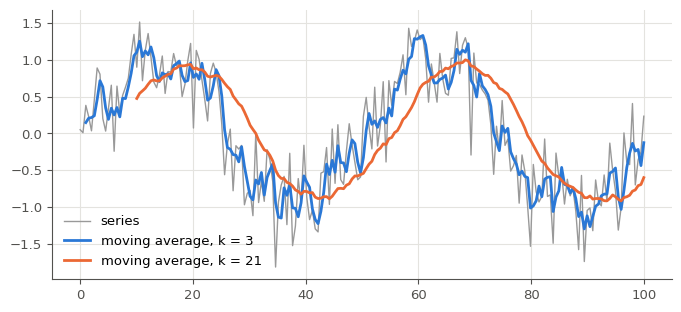

In [36]:
sum_squares = sum(i ** 2 for i in range(1, 51))
product_terms = math.prod(1 + 1 / k for k in range(1, 11))   # 2/1 × 3/2 × ... × 11/10 = 11
weighted = np.average([12, 15, 9, 17], weights=[2, 1, 3, 4])
z = np.array([0.5, -1, 2, 0.1]) @ np.array([4, 1, 0.5, 10]) + 0.5


def moving_average(x, k):
    """Moving averages of order k of the series x (with a loop): len(x) - k + 1 values."""
    return np.array([np.mean(x[t - k + 1:t + 1]) for t in range(k - 1, len(x))])


print(sum_squares, 50 * 51 * 101 // 6, round(product_terms, 6), weighted, z)
print(len(moving_average(series, 9)), moving_average(series, 9)[:3].round(3),
      np.allclose(moving_average(series, 5), np.convolve(series, np.ones(5) / 5, mode="valid")))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_35, series, color="0.6", lw=1, label="series")
for k in (3, 21):
    ax.plot(t_35[k - 1:], moving_average(series, k), lw=2, label=f"moving average, k = {k}")
ax.legend()
plt.show()

In [37]:
wb.record("0B.35a", sum_squares, mistakes={"range(1, 50) s'arrête à 49 : la borne haute d'un Σ est incluse": sum(i ** 2 for i in range(1, 50))})
wb.record("0B.35b", product_terms, decimals=6)
wb.record("0B.35c", weighted, decimals=1, mistakes={"divise par la somme des coefficients (10), pas par le nombre de notes": np.mean([12, 15, 9, 17])})
wb.record("0B.35d", z, decimals=1, mistakes={"n'oublie pas le biais b = 0,5": z - 0.5})
wb.record("0B.35e", len(moving_average(series, 9)), mistakes={"la première moyenne mobile existe à t = k : il y en a n − k + 1": 191})
wb.record("0B.35f", moving_average(series, 9)[:3], decimals=3)

WB_ANSWER {"hash": "bea18bb4e2f52796f472c79099df47ec67051f34bc2c4c1599e6042f0eb9aeef", "id": "0B.35a", "kind": "int", "magnitude": 4, "mistakes": {"b4c97d2ea7ea1300ebff77ab80f2a4a855136840ed2eef3a246080dda2cd39e8": "range(1, 50) s'arrête à 49 : la borne haute d'un Σ est incluse"}, "sign": 1}
📝 Ex 0B.35a : réponse enregistrée (int).
WB_ANSWER {"decimals": 6, "hash": "00eb6bd63e6be4e96e356f23ae4d0cc4058bd4781f491cc69cda0c3d623ce9da", "hash_coarse": "9272424735a4a4fffede6e392ff092f3e85aa8469968640900b2234d2bef517e", "id": "0B.35b", "kind": "float", "magnitude": 1, "sign": 1}
📝 Ex 0B.35b : réponse enregistrée (float, 6 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "584874934a3207d45ba3858d9e3cfaa1bf4528d8609612d728589ff21197abf5", "hash_coarse": "81302c5dabd855d8ca9cf2c49aaf3a29e4bcd05005987c7b8e92aa3f2e203f18", "id": "0B.35c", "kind": "float", "magnitude": 1, "mistakes": {"9b10ef6e38f5344dd43af0ea32775d3fcb78b9fa3e3829ed451c53d1f14f355f": "divise par la somme des coefficients (10), pas 

💡 Le produit « télescopique » $\frac{2}{1} \times \frac{3}{2} \times \dots \times \frac{11}{10}$ se simplifie en $\frac{11}{1}$. Sur la figure, l'ordre 3 garde beaucoup de bruit ; l'ordre 21 suit la sinusoïde, mais avec un retard d'environ 10 pas, car chaque moyenne ne regarde que le passé. `np.convolve` fait le même calcul en code compilé ; `np.cumsum` permet aussi un calcul en temps linéaire (0A).

### Ex 0B.36 — Galerie des fonctions usuelles : de l'affine au cosinus 📦 ★★ ⏱️ 20 min
**Objectif :** tracer et reconnaître les fonctions usuelles du ML avec NumPy et matplotlib.  
**Prérequis :** Ex 0B.6, Ex 0B.17, Ex 0B.7 · fiche §101.2.1 à §101.2.6, §101.1.2 · **Fil rouge :** synthétique · **Parcours :** M, C

1. Écris `sigmoid(x)`, qui calcule $\sigma(x) = \frac{1}{1 + e^{-x}}$ pour un **array** NumPy d'un coup (avec `np.exp`, sans boucle).
2. Écris `gallery()`, qui trace une grille 3 × 3 (`fig, axes = plt.subplots(3, 3, figsize=(11, 8))`, puis `axes.ravel()`) avec, dans l'ordre : $2x - 1$, $x^2 - 2x - 3$, $e^x$, $\ln x$, $\sigma(x)$, $\tanh(x)$, $\cos x$, $|x|$ et $\lfloor x \rfloor$. Pour chaque panneau : un titre (le nom de la fonction) et les axes passant par l'origine (`ax.axhline(0)` et `ax.axvline(0)`). Prends `x = np.linspace(-4, 4, 401)`, sauf pour $\ln$, définie seulement pour $x > 0$ : `np.linspace(0.05, 4, 400)`. `gallery()` renvoie la figure.

Vérifications : a) `sigmoid(np.array([-2.0, 0.0, 2.0]))` (3 décimales) · b) $\tanh(1)$ et $2\sigma(2) - 1$ sont-ils égaux (`np.isclose`, 0B.17) ? · c) la structure de la figure : 9 panneaux, chacun avec un titre et une courbe, et aucune valeur `nan` ou infinie tracée (sinon, un $\ln$ de nombre négatif s'est glissé quelque part).

Regarde ensuite la figure (ta copie) : quelles fonctions sont bornées ? croissantes ? paires ($f(-x) = f(x)$) ? impaires ?

[0.119 0.5   0.881] 0.7615941559557649 0.7615941559557646


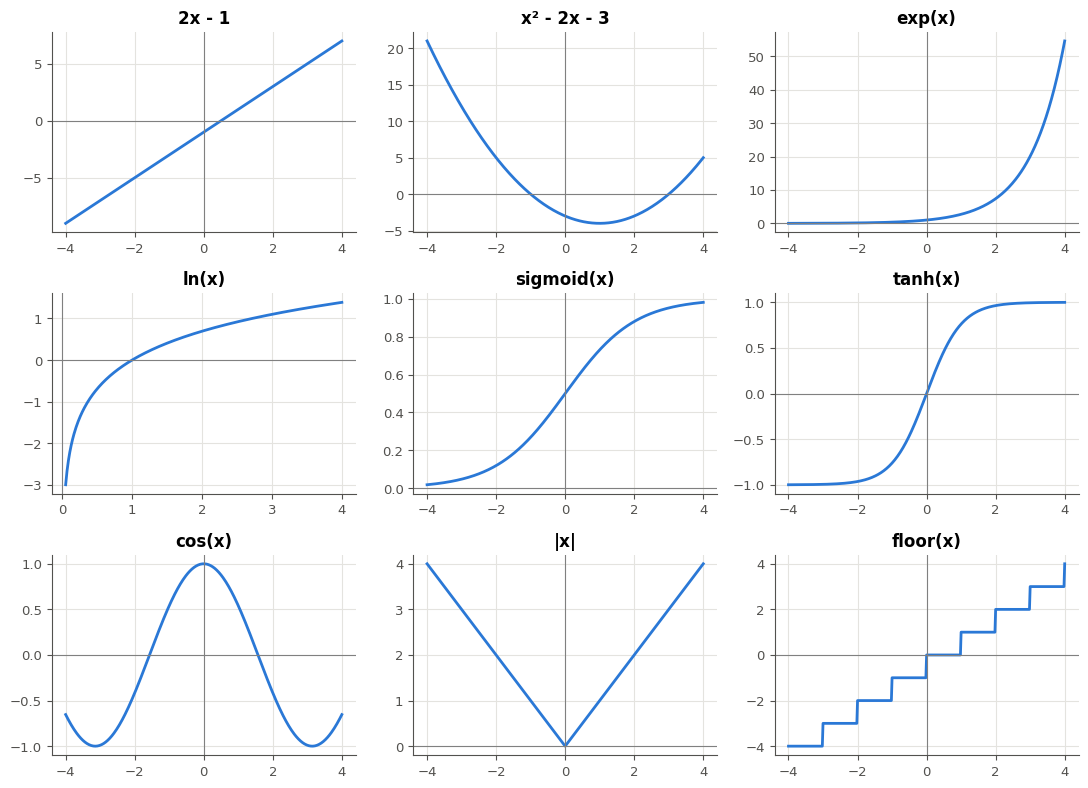

In [38]:
def sigmoid(x):
    """1 / (1 + exp(-x)), computed element-wise on a NumPy array."""
    return 1 / (1 + np.exp(-x))


def gallery():
    """A 3 x 3 figure of the usual functions; returns the figure."""
    x = np.linspace(-4, 4, 401)
    x_pos = np.linspace(0.05, 4, 400)
    panels = [("2x - 1", x, 2 * x - 1), ("x² - 2x - 3", x, x ** 2 - 2 * x - 3), ("exp(x)", x, np.exp(x)),
              ("ln(x)", x_pos, np.log(x_pos)), ("sigmoid(x)", x, sigmoid(x)), ("tanh(x)", x, np.tanh(x)),
              ("cos(x)", x, np.cos(x)), ("|x|", x, np.abs(x)), ("floor(x)", x, np.floor(x))]
    fig, axes = plt.subplots(3, 3, figsize=(11, 8))
    for ax, (title, xs, ys) in zip(axes.ravel(), panels):
        ax.plot(xs, ys, lw=2)
        ax.axhline(0, color="0.5", lw=0.8)
        ax.axvline(0, color="0.5", lw=0.8)
        ax.set_title(title)
    fig.tight_layout()
    return fig


print(sigmoid(np.array([-2.0, 0.0, 2.0])).round(3), np.tanh(1), 2 * sigmoid(np.array(2.0)) - 1)
fig = gallery()
plt.show()

In [39]:
wb.record("0B.36a", sigmoid(np.array([-2.0, 0.0, 2.0])), decimals=3)
wb.record("0B.36b", bool(np.isclose(np.tanh(1), 2 * sigmoid(np.array(2.0)) - 1)))

WB_ANSWER {"decimals": 3, "element_hashes": ["3d58a38e25304b0b887a0e57c7841f1e40f180489f3fd1517a74312c326658a8", "bafa747a5b1d495778ae10815374d268b5ffb5aafc3d153a8e0102092fed2ad7", "cb5126cbdae47511b1e793140940aed0c996dd087dab3db76da9f0cc662c15e8"], "hash": "1f623ac05dbf3d85c1001c420c258e331bc2a479a122e63fc5c8ffa7eef6adf8", "id": "0B.36a", "kind": "array", "shape": [3]}
📝 Ex 0B.36a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"hash": "2d05b8e658f0bfeb883781725763f6476882ab84d074094fab7815d04aea5e13", "id": "0B.36b", "kind": "bool"}
📝 Ex 0B.36b : réponse enregistrée (bool).


💡 Bornées : σ (entre 0 et 1), tanh (entre −1 et 1), cos (entre −1 et 1). Croissantes : l'affine, exp, ln, σ, tanh et la partie entière (en escalier). Paires : $x^2$ n'y est pas (le terme $-2x$ la décentre), mais $|x|$ et $\cos x$ le sont ; impaire : $\tanh$. `np.floor` trace un escalier : matplotlib relie les marches par des segments presque verticaux.

### Ex 0B.37 — `exp` et `log` en NumPy : `-inf`, `nan` et dépassements 🐛 ★★ ⏱️ 15 min
**Objectif :** diagnostiquer les `-inf`, `inf` et `nan` du calcul flottant et les éviter avec les règles des logarithmes.  
**Prérequis :** Ex 0B.36, Ex 0B.15 · fiche §101.2.3, §101.2.4 · **Parcours :** M, C

Les trois fonctions ci-dessous renvoient `-inf`, `inf` ou `nan` avec un simple avertissement (`RuntimeWarning`) : NumPy ne lève **pas** d'erreur, et le calcul continue avec une valeur absurde. Pour chacune, explique la cause dans ta copie (quel nombre sort des limites d'un `float64`, ou du domaine de $\ln$ ?), puis écris la version corrigée, sans changer son nom :

1. `log_prob_all` : utilise $\ln(p_1 p_2 \cdots p_n) = \sum_i \ln p_i$ ;
2. `geometric_mean` : passe par les logarithmes, $\left(\prod_i x_i\right)^{1/n} = \exp\left(\frac{1}{n}\sum_i \ln x_i\right)$ ;
3. `log_shift` doit renvoyer $\ln(1 + x - \min x)$ : 0 pour la plus petite valeur, jamais `nan` ni `-inf` (la fonction `np.log1p(u)` calcule $\ln(1 + u)$ ; cette transformation est courante pour des données positives très étalées).

Vérifications : a) `log_prob_all(probs_37)` (1 décimale) · b) `geometric_mean(values_37)` (1 décimale) · c) `log_shift(durations_37)` (3 décimales) · d) `max_exponent` : le plus grand entier $n$ tel que `np.exp(n)` est encore fini (`np.isfinite`), trouvé avec une boucle. Le dernier essai affiche un `RuntimeWarning: overflow` : c'est normal (tu peux le masquer en plaçant la boucle dans un bloc `with np.errstate(over="ignore"):`).

In [40]:
probs_37 = np.full(1000, 0.3)                 # 1000 independent events, each of probability 0.3
values_37 = np.linspace(100, 10_000, 500)      # 500 positive measurements
durations_37 = np.array([12.0, 15.5, 12.0, 30.0, 18.25])


def log_prob_all(probs):
    """ln of the probability that ALL the independent events happen."""
    return np.log(np.prod(probs))


def geometric_mean(values):
    """(x_1 × x_2 × ... × x_n) ** (1 / n)."""
    return np.prod(values) ** (1 / len(values))


def log_shift(values):
    """ln(1 + x - min x): 0 for the smallest value (buggy version)."""
    return np.log(values - values.mean())


print("log_prob_all:", log_prob_all(probs_37))
print("geometric_mean:", geometric_mean(values_37))
print("log_shift:", log_shift(durations_37))

log_prob_all: -inf
geometric_mean: inf
log_shift: [        nan         nan         nan  2.52172062 -0.35667494]


/tmp/ipykernel_6738/4118460712.py:8: RuntimeWarning: divide by zero encountered in log
  return np.log(np.prod(probs))
/home/claude/venv313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_6738/4118460712.py:18: RuntimeWarning: invalid value encountered in log
  return np.log(values - values.mean())


In [41]:
def log_prob_all(probs):
    return np.sum(np.log(probs))            # the product underflowed to 0, and ln 0 = -inf


def geometric_mean(values):
    return np.exp(np.mean(np.log(values)))  # the product overflowed to inf


def log_shift(values):
    return np.log1p(values - values.min())  # values - mean < 0 below the mean, and the log of a negative number is nan


max_exponent = 0
with np.errstate(over="ignore"):            # hide the overflow warning of the last try
    while np.isfinite(np.exp(max_exponent + 1)):
        max_exponent += 1
print(log_prob_all(probs_37), geometric_mean(values_37), log_shift(durations_37).round(3), max_exponent)

-1203.972804325936 3843.4525609883913 [0.    1.504 0.    2.944 1.981] 709


In [42]:
wb.record("0B.37a", log_prob_all(probs_37), decimals=1)
wb.record("0B.37b", geometric_mean(values_37), decimals=1, mistakes={"c'est la moyenne ordinaire : la moyenne géométrique passe par les logarithmes": values_37.mean()})
wb.record("0B.37c", log_shift(durations_37), decimals=3)
wb.record("0B.37d", max_exponent, mistakes={"vérifie ta condition d'arrêt : on veut le DERNIER n pour lequel np.exp(n) est encore fini": 710})

WB_ANSWER {"decimals": 1, "hash": "fbb0e8c878b0b86c08516bbf790857519c7e7ac4511d8e32618bb2cc9c15a6a4", "hash_coarse": "2156cd224becdc10c7e8630912310e85add7d8d64dbab5406c51519d69fb8e23", "id": "0B.37a", "kind": "float", "magnitude": 3, "sign": -1}
📝 Ex 0B.37a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "2fd941c80e562e97f7f5cef83bcb121c28a92cbf7ea5dcca24a33ab3037372ac", "hash_coarse": "c12dd3a15c39ef7b9f173e43b05cb32dedf76540ad8cd2c0e36d164c10873755", "id": "0B.37b", "kind": "float", "magnitude": 3, "mistakes": {"8f5c6194ae58dd9502b1ec3ba7301e333b491c2bc7a38bef1e029a5d580ad49c": "c'est la moyenne ordinaire : la moyenne géométrique passe par les logarithmes"}, "sign": 1}
📝 Ex 0B.37b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 3, "element_hashes": ["c891d7dd83f535b33deae7e83e386d8587efb6ebf4ec7d132f0750e1b94eebf8", "7691506a30fca44b9efe70dd1de9f7e7018c7cffaeff8c95c75ff2fe4408d71b", "cae0acf3ae5e312b5d27a21c684d73a7857f506f29545dde

💡 1. $0{,}3^{1000} \approx 10^{-523}$ est trop petit pour un `float64` : `np.prod` renvoie 0 (sous-dépassement), et $\ln 0 = -\infty$. 2. Le produit de 500 nombres entre 100 et 10 000 dépasse $10^{308}$ : `inf`. 3. Soustraire la moyenne rend négatives les valeurs sous la moyenne : `nan`. `np.exp` déborde au-delà de $\ln(1{,}8 \times 10^{308}) \approx 709{,}8$. Règle : on garde les grands produits sous forme de sommes de logarithmes (0B.E3).

## Partie B · mylearn.linalg_basics : vecteurs et matrices en Python pur, puis NumPy

Fiche §101.3 et §101.4. Tu écris toi-même, avec des listes et des boucles, ce que cache le `@` de NumPy : sommes de vecteurs, produit scalaire, normes, cosinus, transposée, produit matriciel. Puis tu compares avec NumPy, et tu chasses les bugs de formes.

In [43]:
# Tools and data for part B
p1, p2 = [40, 190], [48, 196]      # two penguins: (bill length, flipper length) in mm (0B.8)


def run_linalg_tests(keyword, impl="learner"):
    """Run the tests of mylearn.linalg_basics selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", "tests/test_ch00b_linalg_basics.py", "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=line"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "200"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    for line in [line for line in lines if line.startswith("FAILED")][:8]:
        print(line[:200])
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


def error_message(func, *args):
    """Message of the exception raised by func(*args), or "no error"."""
    try:
        func(*args)
    except NotImplementedError:
        raise
    except Exception as error:  # noqa: BLE001 - we want the message of whatever is raised
        return str(error)
    return "no error"

### Ex 0B.38 — `linalg_basics` (1) : additionner, soustraire, multiplier des vecteurs 🔨 ★★ ⏱️ 15 min
**Objectif :** écrire les opérations composante par composante sur des vecteurs stockés en listes.  
**Prérequis :** Ex 0B.8 · 0A (listes, `zip`, compréhensions) · fiche §101.3.1, §101.3.4 · **Parcours :** M, C

> **Mode d'emploi mylearn** (comme en 0A.26 et 0A.63) : ouvre `mon_travail/mylearn/linalg_basics.py` (créé par `python tools/start_chapter.py 0B`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. Tout en **Python pur** : des listes, des boucles ou des compréhensions, `math` si besoin, mais **pas de NumPy** dans ce fichier (NumPy est l'oracle des tests). La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de ces fonctions.

Écris `vector_add`, `vector_subtract`, `scalar_multiply` et `hadamard`. Tout se fait **composante par composante** : une compréhension sur `zip(u, v)` suffit. Vérifie d'abord que les deux vecteurs ont la même longueur (sinon, `ValueError`), et renvoie une **nouvelle** liste de `float` (`float(a + b)`), sans modifier les entrées.

Vérifications, avec les deux manchots de 0B.8, `p1` et `p2` : a) `vector_add(p1, p2)` · b) `vector_subtract(p1, p2)` · c) le « manchot moyen » `scalar_multiply(0.5, vector_add(p1, p2))` · d) `hadamard([1, 2, 2], [2, 0, -1])` · e) le nom de l'exception levée par `vector_add([1, 2], [1, 2, 3])` · puis les tests.

In [44]:
lb = mylearn.linalg_basics
print(lb.vector_add(p1, p2), lb.vector_subtract(p1, p2), lb.scalar_multiply(0.5, lb.vector_add(p1, p2)),
      lb.hadamard([1, 2, 2], [2, 0, -1]), error_name(lb.vector_add, [1, 2], [1, 2, 3]))
print("with lists, + concatenates:", p1 + p2)
run_linalg_tests("vector_add or vector_subtract or scalar_multiply or hadamard or elementwise", impl="ref")

[88.0, 386.0] [-8.0, -6.0] [44.0, 193.0] [2.0, 0.0, -2.0] ValueError
with lists, + concatenates: [40, 190, 48, 196]


pytest: 13 passed, 40 deselected in 1.53s


In [45]:
wb.record("0B.38a", lb.vector_add(p1, p2), mistakes={"sur des listes, + les COLLE : additionne composante par composante": p1 + p2})
wb.record("0B.38b", lb.vector_subtract(p1, p2))
wb.record("0B.38c", lb.scalar_multiply(0.5, lb.vector_add(p1, p2)), decimals=1)
wb.record("0B.38d", lb.hadamard([1, 2, 2], [2, 0, -1]))
wb.record("0B.38e", error_name(lb.vector_add, [1, 2], [1, 2, 3]), mistakes={"zip s'arrête silencieusement au plus court : vérifie les longueurs avant": "no error"})

WB_ANSWER {"decimals": 0, "element_hashes": ["4591bfeb3d719bc1f19200d9ceb37f15ee93777b5884cc721f3288234efc24d2", "8d981cdcf3a080f7e7de772cfdd1a7a3582a93e64fcb4a3f6d65f7978bff4b80"], "hash": "a7262f9d7a75298ee649c2a6a413279525197665b4407a314335296f3979ba91", "id": "0B.38a", "integer": true, "kind": "array", "mistakes": {"511d3fd2b0dfd748139211550ced6f3ae2944f3ad4b8578edca8ec1ff476c96b": "sur des listes, + les COLLE : additionne composante par composante"}, "shape": [2]}
📝 Ex 0B.38a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["53c4c09413177853efb6696f1255374fc0b2315505293c905426e19e76f05fd5", "8e15ac1ad196dc406b18fb242ef2e1fdaed7e3187072e622ed28c00c003139a9"], "hash": "6441ef541d570845e7b88c7f6e92bb6886eae4e08b81d584f01fa53aa4257aac", "id": "0B.38b", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.38b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["4caf7c12b7ca64dc4e3ef43ca18313c26ba223cee0

💡 La référence est dans `solutions/mylearn_ref/linalg_basics.py` : lis-la **après** avoir réussi les tests. Le piège de e : `zip` ne signale pas des longueurs différentes, il s'arrête au plus court (depuis Python 3.10, `zip(u, v, strict=True)` lève une `ValueError`).

### Ex 0B.39 — `linalg_basics` (2) : produit scalaire, norme, distance, cosinus 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire le produit scalaire, les normes L1, L2 et L∞, la distance et la similarité cosinus.  
**Prérequis :** Ex 0B.18 · 0A · fiche §101.3.2, §101.3.3 · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme en 0A.26 et 0A.63) : ouvre `mon_travail/mylearn/linalg_basics.py` (créé par `python tools/start_chapter.py 0B`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. Tout en **Python pur** : des listes, des boucles ou des compréhensions, `math` si besoin, mais **pas de NumPy** dans ce fichier (NumPy est l'oracle des tests). La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de ces fonctions.

Écris `dot`, `norm`, `distance` et `cosine_similarity`.
- `norm(v, p=2)` couvre plusieurs normes : `p = 2` (euclidienne), `p = 1` (somme des valeurs absolues), `p = math.inf` (plus grande valeur absolue), et plus généralement $\left(\sum_i |v_i|^p\right)^{1/p}$ pour tout $p \geq 1$.
- `distance` : réutilise `vector_subtract` et `norm` si tu as fait 0B.38 ; sinon, calcule-la directement.
- `cosine_similarity` refuse un vecteur nul (`ValueError`) : l'angle n'est pas défini. Les erreurs d'arrondi peuvent donner `1.0000000000000002` : ramène le résultat dans $[-1, 1]$.

Vérifications : a) `dot([1, 2, 2], [2, 0, -1])` · b) la liste des normes L2, L1 et L∞ de `[3, -4]` · c) `distance(p1, p2)` · d) `cosine_similarity([1, 2, 2], [2, 4, 4])` · e) `cosine_similarity([3, 1], [1, 2])` (3 décimales) · puis les tests.

In [46]:
lb = mylearn.linalg_basics
print(lb.dot([1, 2, 2], [2, 0, -1]), [lb.norm([3, -4]), lb.norm([3, -4], p=1), lb.norm([3, -4], p=math.inf)],
      lb.distance(p1, p2), lb.cosine_similarity([1, 2, 2], [2, 4, 4]), lb.cosine_similarity([3, 1], [1, 2]))
run_linalg_tests("(dot or norm or distance or cosine) and not hadamard", impl="ref")

0.0 [5.0, 7.0, 4.0] 10.0 1.0 0.7071067811865475


pytest: 18 passed, 35 deselected in 1.08s


In [47]:
wb.record("0B.39a", int(lb.dot([1, 2, 2], [2, 0, -1])))
wb.record("0B.39b", [lb.norm([3, -4]), lb.norm([3, -4], p=1), lb.norm([3, -4], p=math.inf)],
          mistakes={"L1 et L∞ utilisent des VALEURS ABSOLUES": [5, -1, 3]})
wb.record("0B.39c", lb.distance(p1, p2), decimals=1)
wb.record("0B.39d", lb.cosine_similarity([1, 2, 2], [2, 4, 4]), decimals=3, mistakes={"le produit scalaire seul ne suffit pas : divise-le par le produit des deux normes": 18.0, "divise par le produit des DEUX normes, pas par une seule": 6.0, "divise par le produit des deux normes, pas par une seule": 3.0})
wb.record("0B.39e", lb.cosine_similarity([3, 1], [1, 2]), decimals=3)

WB_ANSWER {"hash": "9ca89bad07ef5bdb09a72e41e316001b723cb7104aa0533485bacbd95843f056", "id": "0B.39a", "kind": "int", "magnitude": null, "sign": 0}
📝 Ex 0B.39a : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["4f01a25d16895495606f94b51e4746791baa333bcb3f2acb9973829e834c01e8", "739ddd3ae894b9cb413c23620c7c0f2b8b420fdf9e267089f834a01e54993ebd", "5f84eca55af127d4305d0ce682c45d4f345975b0c150eff56266a87eb08ec08b"], "hash": "ef892706cf554c7e0153c5d22dd2928842d1f484d704ff7a9fb7b343e35e61de", "id": "0B.39b", "integer": true, "kind": "array", "mistakes": {"8500bfaa7a42df7678270a582d549da4faf827b83cae1dcff2daad9b916856d2": "L1 et L∞ utilisent des VALEURS ABSOLUES"}, "shape": [3]}
📝 Ex 0B.39b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "8e0f5afcb6b5d6963c629544bbf39e7dfefc5e38b02e37b5a9ea09d2e80eaceb", "hash_coarse": "ec733aff4923f5d4cd97828f89a30a3ba8c87b902d670af9e8b5a0b0a5fbac47", "id": "0B.39c", "kind": "float", "magnitude": 1, "sig

💡 d vaut 1 : les deux vecteurs ont la même direction (le second est le double du premier). e retrouve l'exemple de la fiche, un angle de 45°. `norm` avec `p = math.inf` se traite à part : $|v_i|^{\infty}$ n'a pas de sens en calcul flottant.

### Ex 0B.40 — Tes fonctions contre NumPy : mêmes résultats, autre vitesse 📦 ★★ ⏱️ 15 min
**Objectif :** traduire ses fonctions en appels NumPy, vérifier qu'ils concordent et mesurer l'écart de vitesse.  
**Prérequis :** Ex 0B.39 · fiche §101.3 · **Parcours :** R, M, C

NumPy fait tout cela en une instruction. Pour les arrays `a` et `b` fournis :

a) `np_dot` : leur produit scalaire (`a @ b`) · b) `np_norms` : la liste des normes L2, L1 et L∞ de `a` (`np.linalg.norm(a, ord=...)`, avec `ord=np.inf` pour L∞ ; 2 décimales) · c) `np_cos` : leur similarité cosinus (3 décimales).

Puis compare avec ta librairie (la cellule de vérification s'en charge) : d) sur deux vecteurs aléatoires de dimension 1000 (`u_1000`, `v_1000`), l'écart maximal entre ton `dot` et `np.dot`, ton `norm` et `np.linalg.norm`, ta `cosine_similarity` et la formule NumPy est-il inférieur à $10^{-9}$ ?

e) Écris `speedup_dot()` : avec `measure` (fournie en partie A), le temps de **ton** `dot` sur `u_big` et `v_big` (100 000 composantes, convertis en listes avec `.tolist()` pour ta fonction), divisé par le temps de `np.dot` sur les arrays. La vérification regarde si NumPy est au moins 10 fois plus rapide. D'où vient l'écart (0A.55) ?

In [48]:
a = np.array([2.0, -1.0, 4.0, 0.5])
b = np.array([1.0, 3.0, -2.0, 4.0])
rng_40 = np.random.default_rng(0)
u_1000, v_1000 = rng_40.normal(size=1000), rng_40.normal(size=1000)
u_big, v_big = rng_40.normal(size=100_000), rng_40.normal(size=100_000)

In [49]:
np_dot = a @ b
np_norms = [np.linalg.norm(a), np.linalg.norm(a, ord=1), np.linalg.norm(a, ord=np.inf)]
np_cos = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))


def speedup_dot():
    """(time of YOUR dot on lists) / (time of np.dot on arrays), for u_big and v_big."""
    u_list, v_list = u_big.tolist(), v_big.tolist()
    return measure(mylearn.linalg_basics.dot, u_list, v_list) / measure(np.dot, u_big, v_big)


lb = mylearn.linalg_basics
u_list, v_list = u_1000.tolist(), v_1000.tolist()
gaps = [abs(lb.dot(u_list, v_list) - np.dot(u_1000, v_1000)),
        abs(lb.norm(u_list) - np.linalg.norm(u_1000)),
        abs(lb.cosine_similarity(u_list, v_list) - u_1000 @ v_1000 / (np.linalg.norm(u_1000) * np.linalg.norm(v_1000)))]
speedup = speedup_dot()
print(np_dot, np.round(np_norms, 2), round(np_cos, 3), max(gaps), f"NumPy is {speedup:.0f} times faster")

-7.0 [4.61 7.5  4.  ] -0.277 0.0 NumPy is 285 times faster


In [50]:
wb.record("0B.40a", np_dot, decimals=1)
wb.record("0B.40b", np_norms, decimals=2)
wb.record("0B.40c", np_cos, decimals=3)
wb.record("0B.40d", bool(max(gaps) < 1e-9))
wb.record("0B.40e", bool(speedup >= 10))

WB_ANSWER {"decimals": 1, "hash": "f5eee2fc75c353d58c491b512a8afd0367f86373a4da485287a64b5ab1fba5d7", "hash_coarse": "86f8475d1ffec9e33189dacfa9a650ef743b2b96bca6f6fff57971724580e3b4", "id": "0B.40a", "kind": "float", "magnitude": 0, "sign": -1}
📝 Ex 0B.40a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "element_hashes": ["45eb950d292a375ae03f5f4839487394ca748ad10dd35566c00fac929dbac7b6", "4d6fd26f0c58b58c9cce0bb9d14020e33307e4198484db81b5c81bfecc9dad95", "128db719e7bdd7833fa83e5ef1dcd33c247db9502003108cbbad840e605cdd84"], "hash": "8d2f591f2a0be653618c88584046ebdadf8ff3ead7c0e7ce601fda3d5499f887", "id": "0B.40b", "kind": "array", "shape": [3]}
📝 Ex 0B.40b : réponse enregistrée (array, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "9f9a5b4cef018fed72b07dbb63affa696050eb0f8752224d2a620bf440f146e2", "hash_coarse": "6c5cf40306abb522049840479d317a7228e0f91c27a0bfa79933fb59dd79f93a", "id": "0B.40c", "kind": "float", "magnitude": -1, "sign": -1}
📝 Ex 0B.40c : répo

💡 Les écarts sont nuls ou minuscules (au plus $10^{-14}$ environ) : quand les additions ne se font pas dans le même ordre, l'arrondi flottant peut différer au dernier chiffre. Le rapport de vitesse (souvent 50 à 500) vient, comme en 0A.55, de l'interprétation de chaque instruction Python et des objets `float` créés un par un, que NumPy évite en travaillant sur un bloc de mémoire en code compilé.

### Ex 0B.41 — Distance ou similarité cosinus : l'effet de la longueur 🔬 ★★ ⏱️ 20 min
**Objectif :** comparer distance euclidienne et similarité cosinus sur des sacs de mots, et voir l'effet de la normalisation.  
**Prérequis :** Ex 0B.40 · fiche §101.3.2, §101.3.3 · **Fil rouge :** synthétique · **Parcours :** M, C

Un texte peut être représenté par un **sac de mots** (*bag of words*) : le nombre de fois où chaque mot d'un vocabulaire y apparaît (tu en construiras pour classer des phrases au ch. 13). La requête `query` parle de manchots ; `docs` contient trois documents : un long texte sur les manchots, un court sur les matrices, et un texte mélangé. Tu peux utiliser NumPy ou ta librairie.

a) `nearest_distance` : le **nom** du document le plus proche de `query` au sens de la distance euclidienne (par exemple `min(docs, key=lambda name: ...)`) · b) `nearest_cosine` : le nom de celui qui a la plus grande similarité cosinus avec `query` · c) `nearest_normalized` : le nom du plus proche en distance après avoir **normalisé** tous les vecteurs (chacun divisé par sa norme).

d) Expérience : écris `length_experiment()`, qui multiplie `query` par $k = 1, 2, \dots, 10$ (le même texte, $k$ fois plus long) et renvoie deux listes, `distances` et `cosines` : la distance et la similarité cosinus entre `k * query` et `docs["penguins_long"]`. La vérification regarde si les cosinus sont tous égaux, puis e) la distance pour $k = 10$ (2 décimales), et trace les deux courbes.

Dans ta copie : laquelle des deux mesures dépend de la longueur du texte ? Laquelle choisir pour comparer des textes de longueurs différentes, et que change la normalisation ?

In [51]:
vocabulary = ["penguin", "ice", "fish", "matrix", "vector", "product"]
query = np.array([2.0, 1.0, 1.0, 0.0, 0.0, 0.0])
docs = {
    "penguins_long": np.array([6.0, 4.0, 3.0, 0.0, 1.0, 0.0]),
    "matrices_short": np.array([0.0, 0.0, 0.0, 1.0, 1.0, 1.0]),
    "mixed": np.array([1.0, 0.0, 1.0, 2.0, 1.0, 0.0]),
}

penguins_long   distance 5.48  cosine 0.985  normalized distance 0.173
matrices_short  distance 3.00  cosine 0.000  normalized distance 1.414
mixed           distance 2.65  cosine 0.463  normalized distance 1.036
mixed penguins_long penguins_long [ 5.48  3.16  1.41  2.45  4.69  7.07  9.49 11.92 14.35 16.79] [0.985 0.985 0.985 0.985 0.985 0.985 0.985 0.985 0.985 0.985]


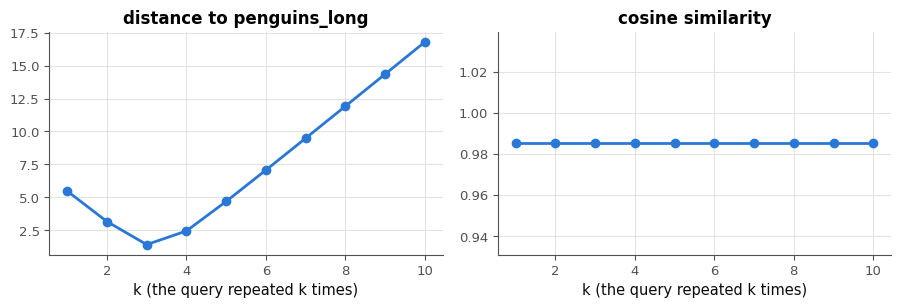

In [52]:
def cosine(u, v):
    return u @ v / (np.linalg.norm(u) * np.linalg.norm(v))


nearest_distance = min(docs, key=lambda name: np.linalg.norm(query - docs[name]))
nearest_cosine = max(docs, key=lambda name: cosine(query, docs[name]))
unit = lambda v: v / np.linalg.norm(v)  # noqa: E731
nearest_normalized = min(docs, key=lambda name: np.linalg.norm(unit(query) - unit(docs[name])))


def length_experiment():
    """Distances and cosine similarities between k * query and docs["penguins_long"], for k = 1..10."""
    target = docs["penguins_long"]
    distances = [np.linalg.norm(k * query - target) for k in range(1, 11)]
    cosines = [cosine(k * query, target) for k in range(1, 11)]
    return distances, cosines


for name, doc in docs.items():
    print(f"{name:15} distance {np.linalg.norm(query - doc):.2f}  cosine {cosine(query, doc):.3f}  "
          f"normalized distance {np.linalg.norm(unit(query) - unit(doc)):.3f}")
distances, cosines = length_experiment()
print(nearest_distance, nearest_cosine, nearest_normalized, np.round(distances, 2), np.round(cosines, 3))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(range(1, 11), distances, marker="o")
axes[0].set_title("distance to penguins_long")
axes[1].plot(range(1, 11), cosines, marker="o")
axes[1].set_title("cosine similarity")
for ax in axes:
    ax.set_xlabel("k (the query repeated k times)")
fig.tight_layout()
plt.show()

In [53]:
wb.record("0B.41a", nearest_distance, mistakes={"le plus PROCHE en distance, c'est la plus PETITE distance (min)": "penguins_long"})
wb.record("0B.41b", nearest_cosine, mistakes={"la plus grande similarité cosinus (max), pas la plus petite": "matrices_short"})
wb.record("0B.41c", nearest_normalized, mistakes={"après normalisation, seule la direction des vecteurs compte, plus leur longueur": "mixed"})
wb.record("0B.41d", bool(np.ptp(cosines) < 1e-9))
wb.record("0B.41e", distances[-1], decimals=2)

WB_ANSWER {"hash": "87adae0d2ffdcb5d37eec2a5e46fe6655acdb465fba8599ee3889696b433b869", "id": "0B.41a", "kind": "str", "mistakes": {"23c90fd5aaf3e799878cc51189e8241147aeaf2c83e8c13514d7fccbaff34810": "le plus PROCHE en distance, c'est la plus PETITE distance (min)"}}
📝 Ex 0B.41a : réponse enregistrée (str).
WB_ANSWER {"hash": "3f2a75df2e44a93b0f84c4de5ef2f9ccd2a556720dfd548101d220f32e636d6c", "id": "0B.41b", "kind": "str", "mistakes": {"4544976523d1448e61542d30aa35536896b9a78b6833f7acf7ac24d0fca2f60a": "la plus grande similarité cosinus (max), pas la plus petite"}}
📝 Ex 0B.41b : réponse enregistrée (str).
WB_ANSWER {"hash": "06a59580cc314ad10cf2446d128dde463db97a241d1a39ab89370f1a61e23688", "id": "0B.41c", "kind": "str", "mistakes": {"60a46ceb9a3e26f65f8e768054ecb5d081233220d04a3c843ea96be0cc9debb0": "après normalisation, seule la direction des vecteurs compte, plus leur longueur"}}
📝 Ex 0B.41c : réponse enregistrée (str).
WB_ANSWER {"hash": "0159c343a21c763a29d59e0d3ec78b94bfedd035ca66

💡 La distance classe en premier le texte « mixed », simplement parce qu'il est court comme la requête ; le texte long sur les manchots est loin, alors qu'il parle du même sujet. La similarité cosinus ne regarde que la direction (les proportions des mots) : répéter un texte ne la change pas. Après normalisation, les deux critères donnent le même classement ($\|\mathbf{a} - \mathbf{b}\|^2 = 2 - 2\cos$, 0B.19) : c'est pourquoi on normalise les embeddings (0B.E2, B2 et B4).

### Ex 0B.42 — `linalg_basics` (3) : forme, transposée, identité, matrice × vecteur 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire la forme, la transposée, l'identité et le produit matrice-vecteur d'une matrice stockée en liste de lignes.  
**Prérequis :** Ex 0B.39, Ex 0B.9 · fiche §101.4.1, §101.4.2, §101.4.4 · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme en 0A.26 et 0A.63) : ouvre `mon_travail/mylearn/linalg_basics.py` (créé par `python tools/start_chapter.py 0B`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. Tout en **Python pur** : des listes, des boucles ou des compréhensions, `math` si besoin, mais **pas de NumPy** dans ce fichier (NumPy est l'oracle des tests). La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de ces fonctions.

Écris `shape`, `transpose`, `identity` et `matvec`. Une matrice est une **liste de lignes**.
- `shape` vérifie que la matrice est bien rectangulaire (au moins une ligne, des lignes non vides et toutes de même longueur ; sinon `ValueError`) ; `transpose` et `matvec` s'en servent pour valider leurs entrées.
- `transpose` : la ligne $j$ du résultat est la colonne $j$ de la matrice.
- `identity(n)` : attention, `[[0.0] * n] * n` crée $n$ fois **la même** liste (fiche 0A, §100.3.1, « mutabilité et alias ») : modifier une ligne les modifierait toutes.
- `matvec(A, v)` : un produit scalaire par ligne (réutilise `dot`) ; si les formes ne vont pas, une `ValueError` dont le message montre les deux formes, par exemple `cannot multiply (2, 3) by (2,)`.

Vérifications, avec les matrices de 0B.9 : a) `shape(A9)` · b) `transpose(A9)` · c) `matvec(A9, [1, 2, -1])` · d) les prédictions $\mathbf{X}\mathbf{w} + b$ de 0B.9 f, avec `matvec`, puis `b` ajouté à chaque composante · e) `matvec(identity(3), [1.5, -2.0, 3.25])` · f) le message d'erreur de `matvec(A9, [1, 2])` contient-il les deux formes `(2, 3)` et `(2,)` ? · puis les tests.

In [54]:
A9 = [[2, 0, 1], [-1, 3, 2]]          # the matrices of 0B.9, as lists of rows
X9 = [[1, 2], [3, 0], [0, -1]]
w9, b9 = [0.5, 2], 1

In [55]:
lb = mylearn.linalg_basics
predictions_9 = [y + b9 for y in lb.matvec(X9, w9)]
message = error_message(lb.matvec, A9, [1, 2])
print(lb.shape(A9), lb.transpose(A9), lb.matvec(A9, [1, 2, -1]), predictions_9,
      lb.matvec(lb.identity(3), [1.5, -2.0, 3.25]), message)
run_linalg_tests("shape_matches or shape_rejects or transpose or identity or matvec", impl="ref")

(2, 3) [[2.0, -1.0], [0.0, 3.0], [1.0, 2.0]] [1.0, 3.0] [5.5, 2.5, -1.0] [1.5, -2.0, 3.25] cannot multiply (2, 3) by (2,)


pytest: 18 passed, 35 deselected in 0.83s


In [56]:
wb.record("0B.42a", lb.shape(A9), mistakes={"(nombre de lignes, nombre de colonnes)": (3, 2)})
wb.record("0B.42b", lb.transpose(A9))
wb.record("0B.42c", lb.matvec(A9, [1, 2, -1]))
wb.record("0B.42d", predictions_9, decimals=1, mistakes={"n'oublie pas le biais b = 1": lb.matvec(X9, w9)})
wb.record("0B.42e", lb.matvec(lb.identity(3), [1.5, -2.0, 3.25]), decimals=2)
wb.record("0B.42f", "(2, 3)" in message and "(2,)" in message)

WB_ANSWER {"decimals": 0, "element_hashes": ["65c350925df4b47e91805525f45f9224befac056d0cb80059dde6cf6c605f22b", "b7f061499c6017afb15335ee92ec7e2c8ed94adf3337f36faf867bb347bd4ff4"], "hash": "05f73c750e83781ed490066e787b13cb01b97b61f91e674e5bde6314efc48c07", "id": "0B.42a", "integer": true, "kind": "array", "mistakes": {"00b83cbc3710fd9312ea28d345ebe659176ade342a7878a4e428626a78c9342d": "(nombre de lignes, nombre de colonnes)"}, "shape": [2]}
📝 Ex 0B.42a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["0cdb125163e8369e16c77322b9242902c39246d6c84173c291c2a50e090bdaa8", "c5b98a6ab572abee07a56ade115b1f75cdc28cd1e842025f5094f6768c1b2e87", "15618c600037eeebd132c1b9c0f7ff238e7e24766f43b61d298f543175cad557", "f3c16dd924a810a0470736cb0a9d4f03058ca65c5ced32dd3592dbd3c9cf808e", "05b29e58c1d98fc662f4cf6e04b21b71d247bc9c7798bec10af4c9a66be84e49", "1a47054a1ca2b60298ae51ec1b7e7d1b045c6e6181f1e7471a62f0637d20e0a8"], "hash": "c2c0f921ba2e6974b605900fe9dee61b4

💡 Un message d'erreur qui montre les formes fait gagner un temps précieux : c'est ce que font NumPy et PyTorch (`mat1 and mat2 shapes cannot be multiplied (64x784 and 128x10)`). `matvec(identity(n), v)` redonne `v` : l'identité joue le rôle du nombre 1.

### Ex 0B.43 — `linalg_basics` (4) : `matmul` et vérification des formes 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire le produit matriciel en Python pur, avec la vérification des formes.  
**Prérequis :** Ex 0B.42, Ex 0B.20 · fiche §101.4.3 · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme en 0A.26 et 0A.63) : ouvre `mon_travail/mylearn/linalg_basics.py` (créé par `python tools/start_chapter.py 0B`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. Tout en **Python pur** : des listes, des boucles ou des compréhensions, `math` si besoin, mais **pas de NumPy** dans ce fichier (NumPy est l'oracle des tests). La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de ces fonctions.

Écris `matmul(A, B)`. Méthode conseillée :
1. les formes, avec `shape` : si le nombre de colonnes de `A` diffère du nombre de lignes de `B`, une `ValueError` dont le message montre les deux formes (`cannot multiply (2, 3) by (2, 2)`) ;
2. `transpose(B)`, pour accéder facilement aux **colonnes** de `B` ;
3. l'élément $(i, j)$ du résultat est `dot(A[i], colonne_j)` : une compréhension imbriquée suffit.

Vérifications, avec les matrices de 0B.20 : a) `matmul(B20, A20)` · b) `shape(matmul(A20, B20))` · c) `matmul(A20, C20)` · d) le nom de l'exception levée par `matmul(C20, A20)` · puis les tests, qui comparent aussi `matmul` à `np.matmul` sur des matrices aléatoires.

In [57]:
A20 = [[1, 2], [0, -1], [3, 1]]      # the matrices of 0B.20
B20 = [[2, 1, 0], [1, -1, 4]]
C20 = [[1, 1], [2, 0]]

In [58]:
lb = mylearn.linalg_basics
print(lb.matmul(B20, A20), lb.shape(lb.matmul(A20, B20)), lb.matmul(A20, C20), error_message(lb.matmul, C20, A20))
print(np.array_equal(lb.matmul(A20, B20), np.array(A20) @ np.array(B20)))
run_linalg_tests("matmul", impl="ref")

[[2.0, 3.0], [13.0, 7.0]] (3, 3) [[5.0, 1.0], [-2.0, 0.0], [5.0, 3.0]] cannot multiply (2, 2) by (3, 2)
True


pytest: 4 passed, 49 deselected in 1.27s


In [59]:
wb.record("0B.43a", lb.matmul(B20, A20))
wb.record("0B.43b", lb.shape(lb.matmul(A20, B20)), mistakes={"(m, n) × (n, p) → (m, p) : on garde les dimensions extérieures": (2, 2)})
wb.record("0B.43c", lb.matmul(A20, C20))
wb.record("0B.43d", error_name(lb.matmul, C20, A20), mistakes={"C est (2, 2) et A (3, 2) : 2 ≠ 3, le produit n'existe pas ; vérifie les formes AVANT de calculer": "no error"})

WB_ANSWER {"decimals": 0, "element_hashes": ["beb273b56c4878be7861641653952dd7db7cc00c60eef3a19e14ae9ad2dda9be", "9fb2a5371d04d5411ad856bb8eebd672c4b6a52b7ddf5707f5898186fa2cb22a", "87a3648f28d181c478914d5fa3a68c33f6f2a46cd0b62f08ef3cee7223f699c7", "0ab20d4f4616cfa3d6f7a05be2988abb93a29a338b5a6d98583e87f52de3b276"], "hash": "da8338067ed145053604a93d81ad84fb2f5d5cee4413dd34fd6d9e27d9892d3c", "id": "0B.43a", "integer": true, "kind": "array", "shape": [2, 2]}
📝 Ex 0B.43a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["423899b19b24f7d57314617b117eddce3c7d2f5efb1bd751225f9227724661b0", "4fcece28ca9ea0c27790d870a90b3ce39af8eab29e233d7fb9184f9380a7f233"], "hash": "78b08cc1c14f32245e8c1df2d4de77cace24603f9752f890b427be4553dcf39a", "id": "0B.43b", "integer": true, "kind": "array", "mistakes": {"f80088a5b5e3293f1e612261c7ea33fb9de8944e5eb537e95c286bdab7fd422a": "(m, n) × (n, p) → (m, p) : on garde les dimensions extérieures"}, "shape": [2]}
📝 Ex 0B.43b

💡 Ta fonction fait exactement $m \times n \times p$ multiplications (0B.20 h), comme la formule $(\mathbf{A}\mathbf{B})_{ij} = \sum_k A_{ik} B_{kj}$. NumPy fait le même calcul, mais découpé en blocs qui tiennent dans la mémoire cache du processeur, et en parallèle : le résultat est identique, la vitesse sans commune mesure (0B.54).

### Ex 0B.44 — AB = BA ? (AB)ᵀ = BᵀAᵀ ? Prédire, puis tester 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir quelles règles de calcul valent pour le produit matriciel, puis les tester sur des exemples.  
**Prérequis :** Ex 0B.43 · fiche §101.4.3 · **Parcours :** R, M, C

**Sans calculer**, prédis `True` (toujours vrai) ou `False` (faux en général) pour des matrices carrées $\mathbf{A}$, $\mathbf{B}$, $\mathbf{C}$ quelconques de même taille :

a) $\mathbf{A}\mathbf{B} = \mathbf{B}\mathbf{A}$ · b) $(\mathbf{A}\mathbf{B})^\top = \mathbf{A}^\top\mathbf{B}^\top$ · c) $(\mathbf{A}\mathbf{B})^\top = \mathbf{B}^\top\mathbf{A}^\top$ · d) $(\mathbf{A}\mathbf{B})\mathbf{C} = \mathbf{A}(\mathbf{B}\mathbf{C})$ · e) $\mathbf{A}(\mathbf{B} + \mathbf{C}) = \mathbf{A}\mathbf{B} + \mathbf{A}\mathbf{C}$ · f) pour deux matrices **diagonales** $\mathbf{D}_1$ et $\mathbf{D}_2$ (des zéros hors de la diagonale) : $\mathbf{D}_1\mathbf{D}_2 = \mathbf{D}_2\mathbf{D}_1$.

Puis l'**Expérience** teste chaque égalité sur des matrices aléatoires à coefficients entiers (des entiers, pour que les égalités soient exactes). Un seul contre-exemple suffit à réfuter une règle ; des milliers d'exemples qui la vérifient ne la démontrent pas, mais donnent confiance.

In [60]:
prediction_0B_44a = False   # not commutative
prediction_0B_44b = False   # the order must be reversed...
prediction_0B_44c = True    # ...like this
prediction_0B_44d = True    # associative
prediction_0B_44e = True    # distributive
prediction_0B_44f = True    # diagonal matrices commute (a special case)

In [61]:
wb.record("0B.44a", prediction_0B_44a, mistakes={"le produit matriciel n'est pas commutatif (fiche §101.4.3) : l'ordre compte": True})
wb.record("0B.44b", prediction_0B_44b, mistakes={"la transposée d'un produit INVERSE l'ordre des facteurs": True})
wb.record("0B.44c", prediction_0B_44c)
wb.record("0B.44d", prediction_0B_44d, mistakes={"le produit est associatif : seul le coût du calcul change (0B.30)": False})
wb.record("0B.44e", prediction_0B_44e)
wb.record("0B.44f", prediction_0B_44f, mistakes={"multiplie deux matrices diagonales 2 × 2 à la main : que devient chaque élément de la diagonale ?": False})

WB_ANSWER {"hash": "8303d3dc664637e7d70afd4da8dc622277e6ffc011b6037c8ceda3c7fa8ead95", "id": "0B.44a", "kind": "bool", "mistakes": {"21ce4b8aa4c5c9da95cdd96e9f434fbf7ef028f17755265a21e4990cce8b5a9d": "le produit matriciel n'est pas commutatif (fiche §101.4.3) : l'ordre compte"}}
📝 Ex 0B.44a : réponse enregistrée (bool).
WB_ANSWER {"hash": "7a59e9488f1356490a6e88d8dace8a53c74621cfe2b312e32d5179f3861a268b", "id": "0B.44b", "kind": "bool", "mistakes": {"8a1fe6a68a875ba852ebc456fb98f95f75dbfb2bcbe437c954c0700ba7905623": "la transposée d'un produit INVERSE l'ordre des facteurs"}}
📝 Ex 0B.44b : réponse enregistrée (bool).
WB_ANSWER {"hash": "c96c26c44edf21e97885df2320509d7b9a63fb7929535185a12b08919b5e28eb", "id": "0B.44c", "kind": "bool"}
📝 Ex 0B.44c : réponse enregistrée (bool).
WB_ANSWER {"hash": "08ad60e34090c4100fcb57522364a4b9e8e8930b710f17f49454485b95c5a45e", "id": "0B.44d", "kind": "bool", "mistakes": {"ac8a452b112c11c729daf2a73b4b137dada417550b4db6867878147b63515fe9": "le produit est

**Expérience** : 1 000 essais par règle, sur des matrices 3 × 3 aléatoires. Une règle est « toujours vraie » ici si aucun essai ne la contredit.

In [62]:
rng_44 = np.random.default_rng(0)
counterexamples = {"a) AB = BA": 0, "b) (AB)T = AT BT": 0, "c) (AB)T = BT AT": 0,
                   "d) (AB)C = A(BC)": 0, "e) A(B + C) = AB + AC": 0, "f) D1 D2 = D2 D1": 0}
for trial in range(1000):
    A, B, C = (rng_44.integers(-5, 6, size=(3, 3)) for _ in range(3))
    D1, D2 = np.diag(rng_44.integers(-5, 6, size=3)), np.diag(rng_44.integers(-5, 6, size=3))
    equalities = [np.array_equal(A @ B, B @ A), np.array_equal((A @ B).T, A.T @ B.T),
                  np.array_equal((A @ B).T, B.T @ A.T), np.array_equal((A @ B) @ C, A @ (B @ C)),
                  np.array_equal(A @ (B + C), A @ B + A @ C), np.array_equal(D1 @ D2, D2 @ D1)]
    for rule, equal in zip(counterexamples, equalities):
        counterexamples[rule] += not equal
for rule, count in counterexamples.items():
    print(f"{rule:24} {'always true here' if count == 0 else f'false in {count} trials out of 1000'}")

a) AB = BA               false in 1000 trials out of 1000
b) (AB)T = AT BT         false in 1000 trials out of 1000
c) (AB)T = BT AT         always true here
d) (AB)C = A(BC)         always true here
e) A(B + C) = AB + AC    always true here
f) D1 D2 = D2 D1         always true here


💡 La non-commutativité est la règle, la commutativité l'exception (matrices diagonales, identité, une matrice et elle-même…). c) se démontre à partir de la formule $(\mathbf{A}\mathbf{B})_{ij} = \sum_k A_{ik} B_{kj}$ ; b) n'a même pas de sens en général pour des matrices rectangulaires, car les formes ne s'emboîtent pas. Retiens : pour transposer un produit, on transpose chaque facteur **et** on inverse l'ordre : on met les chaussettes puis les chaussures, on enlève les chaussures puis les chaussettes.

### Ex 0B.45 — Le produit qui n'en est pas un : `*`, `@`, `(n,)` et `(n, 1)` 🐛 ★★ ⏱️ 20 min
**Objectif :** diagnostiquer les confusions entre produit élément par élément, produit matriciel et formes de vecteurs.  
**Prérequis :** Ex 0B.44 · fiche §101.4.1, §101.4.3, §101.3.4 · **Parcours :** R, C

Trois fonctions d'un modèle linéaire, trois bugs. La cellule fournie les essaie et montre seulement les symptômes : une forme inattendue, une erreur, pas de matrice.

1. `predict(X, w, b)` doit renvoyer **un nombre par exemple**, $\mathbf{X}\mathbf{w} + b$.
2. `layer(X, W, b)` doit renvoyer $\mathbf{X}\mathbf{W} + \mathbf{b}$ : une ligne par exemple, une colonne par neurone.
3. `outer(u, v)` doit renvoyer la matrice de **tous** les produits $u_i v_j$, de forme `(len(u), len(v))` : le produit extérieur (*outer product*) $\mathbf{u}\mathbf{v}^\top$ d'une colonne par une ligne.

Diagnostique d'abord **en raisonnant sur les formes** (écris-les), puis vérifie dans une cellule à toi, avant de corriger : a) la forme renvoyée par la version buggée de `predict`, c'est-à-dire celle de `X45 * w45 + 1.0` (un tuple) · b) le nom de l'exception levée par `W45 @ X45` · c) la valeur de `u45 @ v45.T` (que fait `.T` sur un vecteur de forme `(3,)` ?).

Corrige ensuite les trois fonctions (sans `np.outer`) ; vérifications : d) `predict(X45, w45, 1.0)` · e) `layer(X45, W45, bias45)` · f) `outer(u45, v45)`.

In [63]:
X45 = np.array([[1.0, 2.0, 0.0],
                [0.0, 1.0, 1.0],
                [2.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [3.0, 0.0, 2.0]])              # 5 examples, 3 features
w45 = np.array([0.5, -1.0, 2.0])
W45 = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, -1.0]])   # a layer of 2 neurons: (n_in, n_out) = (3, 2)
bias45 = np.array([0.5, -0.5])
u45, v45 = np.array([1.0, 2.0, 3.0]), np.array([4.0, 5.0, 6.0])


def predict(X, w, b):
    """Predictions X w + b of a linear model: one number per example."""
    return X * w + b


def layer(X, W, b):
    """Outputs X W + b of a dense layer: one row per example, one column per neuron."""
    return W @ X + b


def outer(u, v):
    """The outer product u v^T: the matrix of all the products u_i v_j."""
    return u @ v.T


# Symptoms (without the details: finding them is your job)
print("predict: shape (5,) expected ->", predict(X45, w45, 1.0).shape == (5,))
try:
    layer(X45, W45, bias45)
    print("layer: no error")
except Exception:  # noqa: BLE001
    print("layer: an exception is raised")
print("outer: a 3 x 3 matrix expected ->", np.shape(outer(u45, v45)) == (3, 3))

predict: shape (5,) expected -> False
layer: an exception is raised
outer: a 3 x 3 matrix expected -> False


In [64]:
buggy_predict_shape = (5, 3)      # X * w broadcasts w along each row: element-wise, not a product
buggy_layer_error = "ValueError"  # (3, 2) @ (5, 3): 2 != 5
buggy_outer_value = 32.0          # .T does nothing on a 1-D array: u @ v is the dot product


def predict(X, w, b):
    return X @ w + b                         # (5, 3) @ (3,) -> (5,)


def layer(X, W, b):
    return X @ W + b                         # (5, 3) @ (3, 2) -> (5, 2), then b (2,) broadcast on each row


def outer(u, v):
    return u[:, None] @ v[None, :]           # (3, 1) @ (1, 3) -> (3, 3)


print(predict(X45, w45, 1.0), layer(X45, W45, bias45), outer(u45, v45), sep="\n")

[-0.5  2.   4.   2.5  6.5]
[[ 1.5  1.5]
 [ 1.5 -0.5]
 [ 3.5 -1.5]
 [ 2.5 -0.5]
 [ 5.5 -2.5]]
[[ 4.  5.  6.]
 [ 8. 10. 12.]
 [12. 15. 18.]]


In [65]:
wb.record("0B.45a", buggy_predict_shape)
wb.record("0B.45b", buggy_layer_error)
wb.record("0B.45c", buggy_outer_value, decimals=1)
wb.record("0B.45d", predict(X45, w45, 1.0), decimals=1, mistakes={"le biais b est ajouté à chaque prédiction": predict(X45, w45, 0.0)})
wb.record("0B.45e", layer(X45, W45, bias45), decimals=1)
wb.record("0B.45f", outer(u45, v45), decimals=1)

WB_ANSWER {"decimals": 0, "element_hashes": ["017dfc05246ad96cbdee8296fac9ee1c6e20fba020d17e11ed3f4c8b129faf97", "3e1d8907b92fb830292b590de2553a69fb2fd2e8dcca29eb3f427b5672325390"], "hash": "d25a38765784d435fcc3c291a1f0db388410ce5fdf8d653d944bb4775db5cf9d", "id": "0B.45a", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.45a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "cfdf72505e23c48536da4e6343adb1474e0255f9d1778bfd535063b43035d0db", "id": "0B.45b", "kind": "str"}
📝 Ex 0B.45b : réponse enregistrée (str).
WB_ANSWER {"decimals": 1, "hash": "49a970104c801239d61cf7fee5a796689cf2907f3edaf1470e3e34bc69c9a8d2", "hash_coarse": "908577443d9f2010ee26ab3972e045af7b04bf602b508eed0e3136029d30dc23", "id": "0B.45c", "kind": "float", "magnitude": 1, "sign": 1}
📝 Ex 0B.45c : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["53e47672b8e70bf5beaaaef9a97c4a36cfb318670011452563cc9c96cb19e7f4", "b29acb1c9e65980e573e4066b061bf29b2546cea1feb

💡 Trois réflexes : `*` est élément par élément, `@` est le produit matriciel ; écris les formes avant d'écrire le calcul (`(5, 3) @ (3, 2) → (5, 2)`) ; un vecteur `(n,)` n'est ni une ligne ni une colonne, et `.T` ne le change pas : pour une colonne, `u[:, None]` ou `u.reshape(-1, 1)`. Le bug 1 est le plus dangereux : aucune erreur, juste une forme fausse qui se propagera plus loin.

### Ex 0B.46 — Inverse et systèmes : `np.linalg.inv` et `np.linalg.solve` 📦 ★★ ⏱️ 15 min
**Objectif :** calculer déterminant, inverse et solution d'un système avec NumPy, et savoir pourquoi on préfère `solve`.  
**Prérequis :** Ex 0B.21, Ex 0B.43 · fiche §101.4.4 · **Parcours :** M, C

a) `det_M` : le déterminant de $\mathbf{M}$ (0B.21) avec `np.linalg.det` (6 décimales) ; le calcul est fait en virgule flottante, le résultat peut s'écarter de la valeur exacte au 16ᵉ chiffre.
b) `M_inv` : $\mathbf{M}^{-1}$ avec `np.linalg.inv` (2 décimales) ; vérifie dans ta copie que `M46 @ M_inv` est proche de l'identité (`np.allclose(..., np.eye(2))`).
c) `x_2` : la solution de $3x + y = 5$, $4x + 2y = 6$ avec `np.linalg.solve`.
d) `singular_error` : le nom (court) de l'exception levée par `np.linalg.inv` sur la matrice `singular46` de 0B.21 d, par exemple avec `error_name` (partie A).
e) `x_3` : la solution du système $2x + y - z = 8$, $-3x - y + 2z = -11$, $-2x + y + 2z = -3$ (écris la matrice des coefficients et le second membre).
f) Pour le système aléatoire `A_big` ($500 \times 500$) et `b_big` : `solve_is_accurate`, l'écart $\|\mathbf{A}\mathbf{x} - \mathbf{b}\|$ de `np.linalg.solve` est-il inférieur à $10^{-8}$ ? Dans ta copie, compare aussi avec `np.linalg.inv(A_big) @ b_big` : écarts et temps (`measure`). Lequel choisir ?

In [66]:
M46 = np.array([[3.0, 1.0], [4.0, 2.0]])
singular46 = np.array([[2.0, 4.0], [1.0, 2.0]])
rng_46 = np.random.default_rng(0)
A_big, b_big = rng_46.normal(size=(500, 500)), rng_46.normal(size=500)

In [67]:
det_M = np.linalg.det(M46)
M_inv = np.linalg.inv(M46)
x_2 = np.linalg.solve(M46, [5.0, 6.0])
try:
    np.linalg.inv(singular46)
    singular_error = "no error"
except np.linalg.LinAlgError as error:
    singular_error = type(error).__name__
    print("LinAlgError:", error)
A3 = np.array([[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]])
x_3 = np.linalg.solve(A3, [8.0, -11.0, -3.0])
x_solve = np.linalg.solve(A_big, b_big)
x_inv = np.linalg.inv(A_big) @ b_big
solve_is_accurate = bool(np.linalg.norm(A_big @ x_solve - b_big) < 1e-8)
print(det_M, M_inv, np.allclose(M46 @ M_inv, np.eye(2)), x_2, x_3, sep="\n")
print(f"solve: gap {np.linalg.norm(A_big @ x_solve - b_big):.1e}, {measure(np.linalg.solve, A_big, b_big) * 1000:.1f} ms")
print(f"inv:   gap {np.linalg.norm(A_big @ x_inv - b_big):.1e}, "
      f"{measure(lambda: np.linalg.inv(A_big) @ b_big) * 1000:.1f} ms")

LinAlgError: Singular matrix


2.0
[[ 1.  -0.5]
 [-2.   1.5]]
True
[ 2. -1.]
[ 2.  3. -1.]
solve: gap 1.0e-11, 3.8 ms
inv:   gap 1.8e-11, 12.4 ms


In [68]:
wb.record("0B.46a", det_M, decimals=6)
wb.record("0B.46b", M_inv, decimals=2, mistakes={"n'oublie pas de diviser par le déterminant": [[2, -1], [-4, 3]]})
wb.record("0B.46c", x_2, decimals=2)
wb.record("0B.46d", singular_error)
wb.record("0B.46e", x_3, decimals=2)
wb.record("0B.46f", solve_is_accurate)

WB_ANSWER {"decimals": 6, "hash": "3cd21f152df3b0a1cde610a3adcc8ae3d466a1ac438dde59908c7803eb5d8afc", "hash_coarse": "b5650fc8b02eb103300187eb9f9febf5b31b78fca61594ab444747d2f5fd74ed", "id": "0B.46a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.46a : réponse enregistrée (float, 6 décimale(s)).
WB_ANSWER {"decimals": 2, "element_hashes": ["381de845c70044abdcdac6941dcdeb6698df5c96c86861d5c89583b4269e741e", "aa343b0269894ffa09e4755e837c6c5c387c5b0906e9ee3f5633e444f290a98b", "bfa71e6d593a2f2d489618d26582826715f7151496e25b0c5d9240168716866d", "b98218bf405a4b668399681edba700d53f5a8aa520e872b22549885ed1b70624"], "hash": "4b988ee9cf632cd82d7aae4a569c75643b946a504076458f536663586c25b1e9", "id": "0B.46b", "kind": "array", "mistakes": {"c18e1e62de340a568562be226c593731164ca9a574f499a11d3a0b4a8cdf237a": "n'oublie pas de diviser par le déterminant"}, "shape": [2, 2]}
📝 Ex 0B.46b : réponse enregistrée (array, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "element_hashes": ["22d9a1d68b30ff4a22e4e

💡 `solve` résout le système sans former l'inverse (par élimination, comme au lycée, mais organisée) : environ trois fois moins de calculs, et un résultat au moins aussi précis. Règle pratique : si tu écris `inv(A) @ b`, remplace-le par `solve(A, b)`. L'inverse sert surtout en théorie : par exemple dans la formule des moindres carrés de la régression linéaire (ch. 9).

## Partie C · Dérivées et gradients en code

Fiche §101.5 et §101.6. Une pente centrée de trois lignes suffit pour **vérifier** toutes tes dérivées calculées à la main, lire les variations d'une fonction, dessiner un gradient et tester la somme sur les chemins. (Le choix du pas $h$ et la descente de gradient complète viendront au ch. 5.)

### Ex 0B.47 — Pentes numériques : vérifier tes dérivées à la main 🔨 ★★ ⏱️ 20 min
**Objectif :** estimer une dérivée par une pente centrée et s'en servir pour vérifier des dérivées calculées à la main.  
**Prérequis :** Ex 0B.22, Ex 0B.23 · fiche §101.5.1 à §101.5.3, §101.2.7 · **Parcours :** M, C

a) Écris `centered_slope(f, a, h=1e-5)`, la pente centrée (*central difference*) $\frac{f(a + h) - f(a - h)}{2h}$ (fiche §101.5.1) : une estimation de $f'(a)$, en trois lignes. Vérification a) : `centered_slope(lambda x: x ** 3, 2)` (4 décimales) ; quelle valeur exacte attendais-tu ?

b) Le dictionnaire `functions` (fourni) contient sept fonctions de 0B.22 et 0B.23, chacune avec un intervalle. Remplis le dictionnaire `derivatives` avec **les dérivées que tu as trouvées à la main**, sous forme de `lambda` (par exemple `lambda x: 3 * x ** 2 - 2` pour la fonction $x^3 - 2x$). La vérification compare ta formule à la pente centrée en neuf points de l'intervalle, et signale un point où elle se trompe. C'est le principe du *gradient checking* (ch. 18) : on vérifie une dérivée calculée à la main par une dérivée numérique.

c) La pente centrée de $f(x) = x^2 e^x$ en $x = 1$ (3 décimales) : la même que ta réponse papier à 0B.22 c ?

In [69]:
functions = {   # name: (function, interval where your derivative is compared with the slope)
    "0B.22c": (lambda x: x ** 2 * np.exp(x), (-2, 2)),
    "0B.22d": (lambda x: x * np.log(x), (0.5, 3)),
    "0B.22e": (lambda x: (x + 1) / (x - 1), (1.5, 4)),
    "0B.23b": (lambda x: np.exp(2 * x + 1), (-1, 1)),
    "0B.23c": (lambda x: np.log(x ** 2 + 1), (-2, 2)),
    "0B.23e": (lambda x: np.exp(-x ** 2 / 2), (-2, 2)),
    "0B.23h": (lambda x: np.log(x) ** 2, (0.5, 3)),
}

In [70]:
def centered_slope(f, a, h=1e-5):
    """(f(a + h) - f(a - h)) / (2h): a numerical estimate of f'(a)."""
    return (f(a + h) - f(a - h)) / (2 * h)


derivatives = {
    "0B.22c": lambda x: (x ** 2 + 2 * x) * np.exp(x),          # product rule
    "0B.22d": lambda x: np.log(x) + 1,                          # product rule
    "0B.22e": lambda x: -2 / (x - 1) ** 2,                      # quotient rule
    "0B.23b": lambda x: 2 * np.exp(2 * x + 1),                  # chain rule, u = 2x + 1
    "0B.23c": lambda x: 2 * x / (x ** 2 + 1),                   # chain rule, u = x² + 1
    "0B.23e": lambda x: -x * np.exp(-x ** 2 / 2),               # chain rule, u = -x²/2
    "0B.23h": lambda x: 2 * np.log(x) / x,                      # chain rule, u = ln x
}
for name, (f, (low, high)) in functions.items():
    points = np.linspace(low, high, 9)
    gap = max(abs(derivatives[name](x) - centered_slope(f, x)) for x in points)
    print(f"{name}: largest gap {gap:.1e}")
print(centered_slope(lambda x: x ** 3, 2), centered_slope(functions["0B.22c"][0], 1), 3 * np.e)

0B.22c: largest gap 3.1e-09
0B.22d: largest gap 6.7e-11
0B.22e: largest gap 3.2e-09
0B.23b: largest gap 3.0e-09
0B.23c: largest gap 4.1e-11
0B.23e: largest gap 2.1e-11
0B.23h: largest gap 1.2e-09
12.00000000021184 8.154845485974782 8.154845485377136


In [71]:
wb.record("0B.47a", centered_slope(lambda x: x ** 3, 2), decimals=4)
wb.record("0B.47c", centered_slope(functions["0B.22c"][0], 1), decimals=3)

WB_ANSWER {"decimals": 4, "hash": "f9567528f63b3cd8705d48ef455bb7b6527d469f7b4774524e1ec52eb1dd7b27", "hash_coarse": "650584e440e0563f977c6085ac42459053d04ddc6745c8bf1309f689033c0d91", "id": "0B.47a", "kind": "float", "magnitude": 1, "sign": 1}
📝 Ex 0B.47a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "2973c6e71a0bbbfe8c887b25555d045e7f14929665dabba193c297078dc672ba", "hash_coarse": "39d596d671f5bb98c2633f08f76c9d885c8b0926fe5a730e82b7c12463d12ff6", "id": "0B.47c", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.47c : réponse enregistrée (float, 3 décimale(s)).


💡 Les écarts sont de l'ordre de $10^{-9}$ : la pente centrée est une très bonne approximation (le ch. 5 explique pourquoi, et comment choisir $h$). Une dérivée fausse, elle, se trompe dès le premier chiffre. C'est ainsi qu'on teste une rétropropagation écrite à la main (ch. 18).

### Ex 0B.48 — Lire les variations : f, f′ et les points où f′ s'annule 📈 ★★ ⏱️ 15 min
**Objectif :** relier le signe de la dérivée aux variations d'une fonction, sur un graphique puis par le calcul.  
**Prérequis :** Ex 0B.47 · fiche §101.5.4 · **Fil rouge :** synthétique · **Parcours :** M, C

Pour $f(x) = x^3 - 3x^2 - 9x + 2$ sur $[-2 ; 4{,}5]$ (fournie : `f48`, et la grille `x48`), écris `plot_f_and_slope()`, qui trace deux panneaux l'un sous l'autre (`fig, axes = plt.subplots(2, 1, sharex=True)`) : $f$ en haut, sa pente centrée (0B.47) en bas, avec la droite $y = 0$ (`axhline(0)`) sur les deux ; la fonction renvoie la figure.

Puis **lis les graphiques** :
a) `zeros_of_slope` : les deux abscisses où $f'$ s'annule (des entiers, dans l'ordre croissant) ;
b) `nature_left` : en la plus petite, $f$ a-t-elle un `"maximum"` ou un `"minimum"` local ?
c) `f_min` : la plus petite valeur de $f$ sur l'intervalle, calculée sur la grille (`f48(x48).min()`, 1 décimale) ;
d) `f_local_max` : la valeur de $f$ en son maximum local.

Enfin, dans ta copie : dérive $f$ à la main, factorise $f'(x)$ et retrouve a).

In [72]:
def f48(x):
    return x ** 3 - 3 * x ** 2 - 9 * x + 2


x48 = np.linspace(-2, 4.5, 651)   # a grid with a step of 0.01

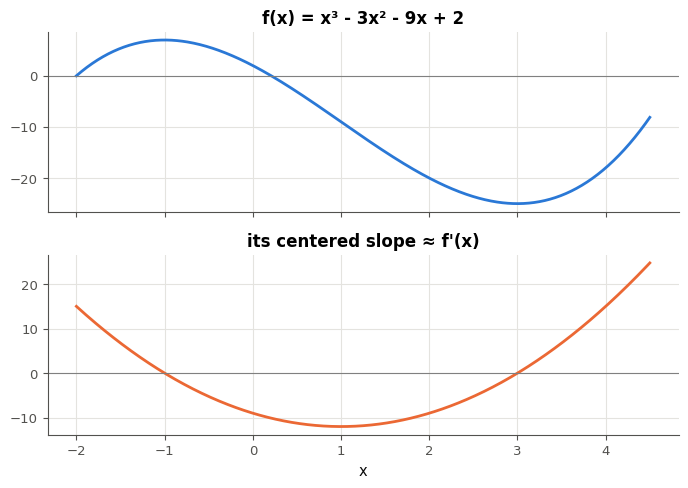

[-1, 3] maximum -25.0 7 3.0


In [73]:
def plot_f_and_slope():
    """Two panels: f48 on top, its centered slope below (with y = 0 on both); returns the figure."""
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7, 5))
    axes[0].plot(x48, f48(x48), lw=2)
    axes[0].set_title("f(x) = x³ - 3x² - 9x + 2")
    axes[1].plot(x48, centered_slope(f48, x48), lw=2, color="C1")   # centered_slope works on arrays too
    axes[1].set_title("its centered slope ≈ f'(x)")
    for ax in axes:
        ax.axhline(0, color="0.5", lw=0.8)
        ax.grid(True)
    axes[1].set_xlabel("x")
    fig.tight_layout()
    return fig


fig = plot_f_and_slope()
plt.show()
zeros_of_slope = [-1, 3]       # read on the lower panel; f'(x) = 3x² - 6x - 9 = 3(x + 1)(x - 3)
nature_left = "maximum"        # f' goes from + to -
f_min = f48(x48).min()
f_local_max = f48(-1)
print(zeros_of_slope, nature_left, f_min, f_local_max, x48[np.argmin(f48(x48))])

In [74]:
wb.record("0B.48a", zeros_of_slope)
wb.record("0B.48b", nature_left, mistakes={"f′ passe de positive à négative : f monte, puis descend": "minimum"})
wb.record("0B.48c", f_min, decimals=1)
wb.record("0B.48d", f_local_max, decimals=1)

WB_ANSWER {"decimals": 0, "element_hashes": ["942eceb396e1535e877b1d79a89331f966915ee7881016a52c31884fe66a4908", "2b42b78d1b152e4f9a93202e7e6cbd10c0b257c0527947dae1753824095e68f4"], "hash": "e757c87377200aba2e869ead575bda7fbc84542cce537135515d2862938c6b89", "id": "0B.48a", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.48a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "33c4f23a888cf32f5e5e37b1fbdd89697b9135d57a1e1ae0cb4c966904f18a54", "id": "0B.48b", "kind": "str", "mistakes": {"6fec26e44e461b51aa1be70bc78dbf859a6b8dc7c7ee10763e76f2f648b1eca5": "f′ passe de positive à négative : f monte, puis descend"}}
📝 Ex 0B.48b : réponse enregistrée (str).
WB_ANSWER {"decimals": 1, "hash": "9afb20147e3d6c6d03654522f0a8985353d970a52241641ab1b42d6a201c6171", "hash_coarse": "188822ddaa5d2755cd83e032e187de16fa350d48ed50ffa9c68c9ccd04b21453", "id": "0B.48c", "kind": "float", "magnitude": 1, "sign": -1}
📝 Ex 0B.48c : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"hash

💡 $f'(x) = 3x^2 - 6x - 9 = 3(x + 1)(x - 3)$ : positive, puis négative entre −1 et 3, puis positive. Le minimum sur l'intervalle est atteint en $x = 3$ ($f(3) = -25$), qui est aussi le minimum local ; sur un intervalle plus grand, il faudrait aussi regarder les bornes. Pour une loss, on cherche de même les points où la dérivée s'annule, mais on ne sait pas les calculer : on les approche pas à pas (ch. 5).

### Ex 0B.49 — Carte de lignes de niveau et flèches du gradient 📈 ★★ ⏱️ 20 min
**Objectif :** tracer les lignes de niveau et le champ de gradient d'une fonction de deux variables, et les lire.  
**Prérequis :** Ex 0B.25, Ex 0B.48 · fiche §101.6.1, §101.6.3 · **Fil rouge :** synthétique · **Parcours :** M, C

Pour $f(x, y) = (x - 1)^2 + 2y^2$ (0B.25, fournie : `f49`) :

1. Écris `grad_f49(x, y)`, qui renvoie le gradient **calculé à la main**, sous forme de tuple `(∂f/∂x, ∂f/∂y)` ; elle doit marcher avec des arrays NumPy (pas de `if`).
2. Écris `level_map()`, qui trace sur une même figure : les lignes de niveau 1, 2, 3, 4, 5 et 6 (`ax.contour(X, Y, Z, levels=[...])`, avec `X, Y = np.meshgrid(...)` sur $[-2 ; 4] \times [-2 ; 2]$) ; les flèches du gradient sur une grille plus grossière (`ax.quiver(Xc, Yc, Gx, Gy)`) ; le point $(3, 1)$ ; et `ax.set_aspect("equal")`, sans quoi les angles sont déformés. La fonction renvoie la figure.

Lis ensuite la carte :
a) le gradient en $(3, 1)$ : la vérification appelle ta fonction, `grad_f49(3, 1)` ;
b) `arrows_vanish_at` : le point où les flèches disparaissent (le gradient est nul) ;
c) `perpendicular` : les flèches coupent-elles les lignes de niveau à angle droit ? (`True`/`False`)
d) `steeper_axis` : en s'éloignant du minimum d'une même distance, $f$ monte-t-elle plus vite selon l'axe `"x"` ou selon l'axe `"y"` ? (regarde dans quelle direction les lignes de niveau sont les plus serrées)

In [75]:
def f49(x, y):
    return (x - 1) ** 2 + 2 * y ** 2

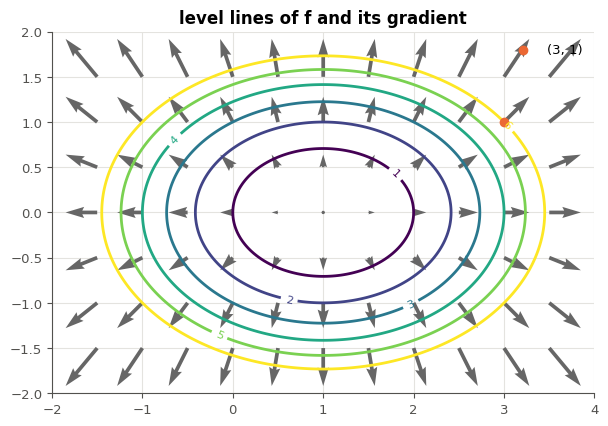

[4.0, 4.0] [1, 0] True y


In [76]:
import matplotlib


def grad_f49(x, y):
    """The gradient of f49 at (x, y), computed by hand: (df/dx, df/dy)."""
    return 2 * (x - 1), 4 * y


def level_map():
    """Level lines 1 to 6 of f49, gradient arrows and the point (3, 1); returns the figure."""
    X, Y = np.meshgrid(np.linspace(-2, 4, 200), np.linspace(-2, 2, 200))
    Xc, Yc = np.meshgrid(np.linspace(-1.5, 3.5, 11), np.linspace(-1.5, 1.5, 7))
    Gx, Gy = grad_f49(Xc, Yc)
    fig, ax = plt.subplots(figsize=(7, 4.8))
    contours = ax.contour(X, Y, f49(X, Y), levels=[1, 2, 3, 4, 5, 6])
    ax.clabel(contours, fontsize=8)
    ax.quiver(Xc, Yc, Gx, Gy, color="0.4", angles="xy")
    ax.scatter([3], [1], color="C1", zorder=3, label="(3, 1)")
    ax.set_aspect("equal")
    ax.legend()
    ax.set_title("level lines of f and its gradient")
    return fig


fig = level_map()
plt.show()
grad_at_3_1 = list(grad_f49(3.0, 1.0))
arrows_vanish_at = [1, 0]
perpendicular = True
steeper_axis = "y"
print(grad_at_3_1, arrows_vanish_at, perpendicular, steeper_axis)

In [77]:
wb.record("0B.49a", grad_at_3_1, mistakes={"∂(2y²)/∂y = 4y": [4, 2]})
wb.record("0B.49b", arrows_vanish_at)
wb.record("0B.49c", perpendicular)
wb.record("0B.49d", steeper_axis, mistakes={"les ellipses sont plus étroites dans quelle direction ? Regarde le coefficient devant y²": "x"})

WB_ANSWER {"decimals": 0, "element_hashes": ["5cca5ca8adce91c7c65d3ce839534d57470bb85e863dab13834419fc1b054885", "0d4a8ed3e6a7ba7616efc525988e7e1e8f17ee81df8eeffd6678732d7416b706"], "hash": "e4d04d38a25ba3f5ab07615b9ff6ece7d4e105175bec9cef029aba80d428e640", "id": "0B.49a", "integer": true, "kind": "array", "mistakes": {"14a01283ced4c5f6eb6b3fba2d536e01bec69a0bec636f02819b9a4522721f9f": "∂(2y²)/∂y = 4y"}, "shape": [2]}
📝 Ex 0B.49a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["639de2bceca73075ba1b1799c31c1447264e085592a9031bb70fe7eac97dcd16", "b79f69f38c9bb59d1fe565d0e214631efaae2f626ffb9389bf30a69d0b950451"], "hash": "6facc19c4a77b9709de1a199f8b23e10ac9a154559bec01bf544b30c58f2f5ad", "id": "0B.49b", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 0B.49b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "ad6c89df07387d800184341f0547902354c26ab9e0ac035bdd543747e5cb716e", "id": "0B.49c", "kind": "bool"}
📝 Ex 0B.49c : réponse

💡 Le gradient est perpendiculaire aux lignes de niveau et pointe vers les niveaux croissants ; il s'annule au minimum $(1, 0)$. Les ellipses sont $\sqrt{2}$ fois plus « serrées » selon $y$ (coefficient 2 devant $y^2$) : $f$ monte plus vite dans cette direction. Une loss en forme d'ellipses très allongées rend la descente de gradient lente (elle zigzague) : c'est une raison de standardiser les features (ch. 12) et d'utiliser les optimiseurs du ch. 19.

### Ex 0B.50 — Contre le gradient, avec lui ou le long d'une ligne de niveau : où va f ? 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir l'effet d'un petit pas selon la direction choisie par rapport au gradient, puis le mesurer.  
**Prérequis :** Ex 0B.49 · fiche §101.6.3 · **Fil rouge :** synthétique · **Parcours :** M

Toujours $f(x, y) = (x - 1)^2 + 2y^2$. Depuis $\mathbf{p} = (3, 1)$, où $\nabla f = (4, 4)$, on fait un petit pas de longueur 0,01 dans quatre directions : a) **contre** le gradient ; b) **dans le sens** du gradient ; c) **le long de la ligne de niveau** qui passe par $\mathbf{p}$ (perpendiculairement au gradient) ; d) selon l'axe des $x$, vers la droite.

Pour chacune, prédis si $f$ va `"baisser"`, `"monter"` ou rester `"stable"` (variation négligeable devant celle des autres directions). Écris ton hypothèse, tes prédictions, puis lance l'**Expérience**, qui calcule les variations $\Delta f$.

e) et f) Après l'expérience : parmi les 360 directions $(\cos\theta, \sin\theta)$, pour $\theta = 0°, 1°, \dots, 359°$, cherche celle où $f$ baisse le plus après un pas de longueur donnée. `best_angle_small` : l'angle (en degrés, un entier) pour un pas de 0,01 ; `best_angle_big` : le même pour un grand pas, de 0,5. Dans ta copie : compare ces deux angles avec celui de la direction $-\nabla f$ et avec celui de la direction qui va de $\mathbf{p}$ au minimum $(1, 0)$ (l'angle d'un vecteur $(d_x, d_y)$ : `np.degrees(np.arctan2(dy, dx)) % 360`). Que garantit le gradient, et pour quels pas ?

In [78]:
def f50(x, y):
    return (x - 1) ** 2 + 2 * y ** 2


p50 = np.array([3.0, 1.0])
unit_grad = np.array([4.0, 4.0]) / np.linalg.norm([4.0, 4.0])    # the gradient at p50, scaled to length 1

In [79]:
prediction_0B_50a = "baisser"
prediction_0B_50b = "monter"
prediction_0B_50c = "stable"
prediction_0B_50d = "monter"   # df/dx = 4 > 0 at p50

In [80]:
wb.record("0B.50a", prediction_0B_50a, mistakes={"contre le gradient, on va dans la direction de plus forte DESCENTE": "monter"})
wb.record("0B.50b", prediction_0B_50b, mistakes={"le gradient indique la direction où f MONTE le plus vite": "baisser"})
wb.record("0B.50c", prediction_0B_50c, mistakes={"le long d'une ligne de niveau, f garde (presque) la même valeur": "baisser"})
wb.record("0B.50d", prediction_0B_50d, mistakes={"regarde le signe de ∂f/∂x en (3, 1)": "baisser", "∂f/∂x n'est pas nul en (3, 1) : regarde son signe": "stable"})

WB_ANSWER {"hash": "87da273d9092e82037d12225a9aca2fa01abfa094efcf6f6a0f87191d4ce8472", "id": "0B.50a", "kind": "str", "mistakes": {"8e11704117a30705e616887c950447b2dcf1abc215669fc2596fc00cc5a6124f": "contre le gradient, on va dans la direction de plus forte DESCENTE"}}
📝 Ex 0B.50a : réponse enregistrée (str).
WB_ANSWER {"hash": "44bdddcc151deeb23d484306bf7d41921705ad72320edf52ac6b0d4f73c2c0d6", "id": "0B.50b", "kind": "str", "mistakes": {"8aa5b31e7a561978f620105f1f8a6c10ffa8ed27f86dda85610bec9970b3b3f0": "le gradient indique la direction où f MONTE le plus vite"}}
📝 Ex 0B.50b : réponse enregistrée (str).
WB_ANSWER {"hash": "5e036db8a334290255bd60607563da36a57a8c600f8a7b57dd34140399d094ef", "id": "0B.50c", "kind": "str", "mistakes": {"563b9279eba447a771fec7079adb98c58b7102cf7e7cf44915c341b03c0d545a": "le long d'une ligne de niveau, f garde (presque) la même valeur"}}
📝 Ex 0B.50c : réponse enregistrée (str).
WB_ANSWER {"hash": "1beb4fe210980fc767228de893a351c0d554d836497d08f16d05dcdbdf9a

**Expérience** : la variation de $f$ après un pas de 0,01 dans chaque direction.

In [81]:
directions_50 = {
    "a) against the gradient": -unit_grad,
    "b) along the gradient": unit_grad,
    "c) along the level line": np.array([-unit_grad[1], unit_grad[0]]),
    "d) along the x axis": np.array([1.0, 0.0]),
}
for name, direction in directions_50.items():
    new_point = p50 + 0.01 * direction
    print(f"{name:26} delta f = {f50(*new_point) - f50(*p50):+.6f}")

a) against the gradient    delta f = -0.056419
b) along the gradient      delta f = +0.056719
c) along the level line    delta f = +0.000150
d) along the x axis        delta f = +0.040100


e) et f) Les 360 directions, un degré à la fois.

In [82]:
def best_angle(step):
    """The direction (in degrees) where f50 decreases the most after a step of this length from p50."""
    angles = np.arange(360)
    radians = np.radians(angles)
    changes = f50(p50[0] + step * np.cos(radians), p50[1] + step * np.sin(radians)) - f50(*p50)
    return int(angles[np.argmin(changes)])


best_angle_small = best_angle(0.01)
best_angle_big = best_angle(0.5)
print(best_angle_small, best_angle_big, np.degrees(np.arctan2(0 - 1, 1 - 3)) % 360)

225 220 206.565051177078


In [83]:
wb.record("0B.50e", best_angle_small, mistakes={"cherche la plus forte BAISSE (argmin), pas la plus forte hausse": 45})
wb.record("0B.50f", best_angle_big, mistakes={"refais la recherche avec un pas de 0,5 : la meilleure direction n'est plus exactement celle du gradient": 225})

WB_ANSWER {"hash": "7cb8c29b577540d6405f51c06ad4dbc6bc614cf9835d499411fb931f538bbfb0", "id": "0B.50e", "kind": "int", "magnitude": 2, "mistakes": {"6cdc70ea490470f5ae7f757cc1078c29d84d0fa2b6138d05155f54cc4790a21f": "cherche la plus forte BAISSE (argmin), pas la plus forte hausse"}, "sign": 1}
📝 Ex 0B.50e : réponse enregistrée (int).
WB_ANSWER {"hash": "0412299eadc4fd5a1d0c1d594fcf3a44785d4099d90675a7c482e99da80aecb5", "id": "0B.50f", "kind": "int", "magnitude": 2, "mistakes": {"ce35aeb19400d3ba18a8e21ed1ca37fa1bf94a5bc600100bf446d785dbd37f15": "refais la recherche avec un pas de 0,5 : la meilleure direction n'est plus exactement celle du gradient"}, "sign": 1}
📝 Ex 0B.50f : réponse enregistrée (int).


💡 Le pas le long de la ligne de niveau change $f$ d'environ $10^{-4}$, près de 400 fois moins que les autres : à cette échelle, $f$ ne varie qu'au second ordre. Pour un petit pas, la meilleure direction est 225°, exactement $-\nabla f$, et la baisse vaut environ $0{,}01 \times \|\nabla f\| \approx 0{,}057$ : la norme du gradient mesure la pente la plus forte (fiche §101.6.3). Pour un pas de 0,5, la meilleure direction tourne vers le minimum (220°) : le gradient ne donne que la meilleure direction **locale**. D'où les petits pas (le learning rate) et les pas répétés de la descente de gradient (ch. 5).

### Ex 0B.51 — Dérivées partielles numériques et somme sur les chemins 🔨 ★★ ⏱️ 25 min
**Objectif :** estimer des dérivées partielles par des pentes centrées et vérifier des dérivées par la somme sur les chemins.  
**Prérequis :** Ex 0B.29, Ex 0B.47 · fiche §101.6.2, §101.6.4 · **Parcours :** M, C

a) Écris `partial_x(f, x, y, h=1e-5)` et `partial_y(f, x, y, h=1e-5)` : des pentes centrées selon une seule variable, l'autre restant fixe. Puis `numerical_gradient(f, x, y)`, qui renvoie `[∂f/∂x, ∂f/∂y]`. Vérification a) : le gradient numérique de $g(x, y) = x^2 y + y^3$ en $(1, 2)$ (fournie : `g51` ; 2 décimales ; compare avec 0B.25 i et j).

b) Partie A de 0B.29 : $z = u^2 + uv$ avec $u = 2x$ et $v = x^2$ (fournie : `z_of_x`). Écris `dz_dx_paths(x)`, la dérivée par la **somme sur les chemins**, avec les dérivées locales de ton graphe de 0B.29 (calcule d'abord $u$ et $v$, puis ajoute les deux chemins). La vérification la compare à la pente centrée de `z_of_x` en plusieurs points, puis regarde b) `dz_dx_paths(1)` (2 décimales).

c) à e) Partie B de 0B.29 : la loss `loss51(w, b)` $= (w \cdot 1 + b - 3)^2 + (w \cdot 2 + b - 4)^2$ est fournie. Écris `grad_paths(w, b)`, qui renvoie `[∂L/∂w, ∂L/∂b]` sous forme de sommes sur les chemins (à travers $\hat{y}_1$ et $\hat{y}_2$), puis `one_step(w, b, eta)`, qui renvoie le point `[w, b]` après un pas de descente de gradient. Vérifications : c) `numerical_gradient(loss51, 1, 0)` (2 décimales) · d) `grad_paths` coïncide-t-elle avec le gradient numérique, en 20 points au hasard ? · e) la loss après un pas depuis $(1, 0)$ avec $\eta = 0{,}1$ (2 décimales).

In [84]:
def g51(x, y):
    return x ** 2 * y + y ** 3


def z_of_x(x):
    u, v = 2 * x, x ** 2
    return u ** 2 + u * v


def loss51(w, b):
    """Squared errors of y_hat = w x + b on the two examples (1, 3) and (2, 4)."""
    return (w * 1 + b - 3) ** 2 + (w * 2 + b - 4) ** 2

In [85]:
def partial_x(f, x, y, h=1e-5):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)


def partial_y(f, x, y, h=1e-5):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)


def numerical_gradient(f, x, y):
    """[df/dx, df/dy] estimated with centered slopes."""
    return [partial_x(f, x, y), partial_y(f, x, y)]


def dz_dx_paths(x):
    """dz/dx for z = u² + u v, u = 2x, v = x², as a sum over the two paths."""
    u, v = 2 * x, x ** 2
    return (2 * u + v) * 2 + u * (2 * x)     # path through u + path through v


def grad_paths(w, b):
    """[dL/dw, dL/db] for loss51, as sums over the paths through y_hat_1 and y_hat_2."""
    (x1, y1), (x2, y2) = (1, 3), (2, 4)
    e1, e2 = w * x1 + b - y1, w * x2 + b - y2          # dL/dy_hat_i = 2 e_i
    return [2 * e1 * x1 + 2 * e2 * x2, 2 * e1 * 1 + 2 * e2 * 1]


def one_step(w, b, eta):
    """The point [w, b] after one gradient descent step of learning rate eta."""
    dw, db = grad_paths(w, b)
    return [w - eta * dw, b - eta * db]


rng_51 = np.random.default_rng(51)
trials = rng_51.uniform(-3, 3, size=(20, 2))
paths_ok = all(np.allclose(grad_paths(w, b), numerical_gradient(loss51, w, b), rtol=1e-5, atol=1e-5) for w, b in trials)
print(numerical_gradient(g51, 1, 2), dz_dx_paths(1), numerical_gradient(loss51, 1, 0), paths_ok,
      one_step(1, 0, 0.1), loss51(1, 0), loss51(*one_step(1, 0, 0.1)))

[4.000000000026205, 13.00000000021839] 14 [-12.000000000078613, -8.00000000005241] True [2.2, 0.8] 8 1.4400000000000004


In [86]:
wb.record("0B.51a", numerical_gradient(g51, 1, 2), decimals=2)
wb.record("0B.51b", dz_dx_paths(1), decimals=2, mistakes={"deux chemins mènent de x à z : additionne-les": (2 * 2 + 1) * 2})
wb.record("0B.51c", numerical_gradient(loss51, 1, 0), decimals=2)
wb.record("0B.51d", paths_ok)
wb.record("0B.51e", loss51(*one_step(1, 0, 0.1)), decimals=2, mistakes={"on descend : on SOUSTRAIT eta fois le gradient": loss51(1 + 0.1 * -12, 0 + 0.1 * -8)})

WB_ANSWER {"decimals": 2, "element_hashes": ["b990621b92f167b408249e3653af02633c44357c09695f309bf89f1bf1a173d8", "f1c9916198a9afd23a607b752540336443dc243df52175a15ee53c44116d8772"], "hash": "09b4c127d2f0c672d2ab35ff0ebb3ed2fcbd83828a718277cc4a0b04559d1bae", "id": "0B.51a", "kind": "array", "shape": [2]}
📝 Ex 0B.51a : réponse enregistrée (array, 2 décimale(s)).
WB_ANSWER {"hash": "d6c271128ce237f6b363741bd4af4a2b77f17f04b88ab75729a17f2d2924d1bd", "id": "0B.51b", "kind": "int", "magnitude": 1, "mistakes": {"ad4de79034e19a0120b5bacfa83f13ac1ec4fc9e262cde757aded1dec273d4ad": "deux chemins mènent de x à z : additionne-les"}, "sign": 1}
📝 Ex 0B.51b : réponse enregistrée (int).
WB_ANSWER {"decimals": 2, "element_hashes": ["20d56e4ceb54c28c0807fc6ed798b834e45be22a42ad0a11a4474f8fa0ad8e9a", "a686379113a681d335b2a142c61987515f2c354fa11e32795b340747dc91eff7"], "hash": "2dd774733da5a7c61355e03449ac2f75d3e25f083811ae1240391a69f084f5ad", "id": "0B.51c", "kind": "array", "shape": [2]}
📝 Ex 0B.51c : r

💡 La somme sur les chemins donne exactement la dérivée ; la pente centrée ne fait que l'estimer, mais suffit à détecter une erreur. Un réseau de neurones a des millions de chemins : la rétropropagation (ch. 18) organise ce calcul en partant de la loss, et la pente numérique sert à la vérifier sur de petits exemples.

## Partie D · Probabilités simulées et défi final

Fiche §101.7 et §101.4.3. Simuler, c'est vérifier un calcul de probabilité, d'espérance ou de variance par l'expérience. Quand un exercice tire des nombres au hasard, l'énoncé impose **exactement** les appels au générateur, pour que tes nombres soient ceux du corrigé.

### Ex 0B.52 — Simuler des dés : fréquences, indépendance, loi des grands nombres 🔬 ★★ ⏱️ 25 min
**Objectif :** estimer des probabilités par simulation, tester une indépendance et voir la loi des grands nombres à l'œuvre.  
**Prérequis :** Ex 0B.26 · 0A (`default_rng`, masques) · fiche §101.7.1, §101.7.2, §101.7.5 · **Fil rouge :** synthétique · **Parcours :** R, M, C

On simule $n = 100\,000$ lancers de deux dés, **exactement** ainsi : `rng = np.random.default_rng(0)`, puis `rolls = rng.integers(1, 7, size=(n, 2))`, `d1 = rolls[:, 0]` et `d2 = rolls[:, 1]`. La fréquence d'un événement est la moyenne d'un masque booléen (par exemple `(d1 == 1).mean()`).

a) `freq_sum_7` : la fréquence de « la somme vaut 7 » (3 décimales) ; compare avec $\frac{1}{6}$.
b) `gaps` : avec $A$ = « le premier dé est pair », $B$ = « la somme vaut 7 » et $C$ = « la somme vaut 8 », la liste des deux écarts $f(A \cap B) - f(A)\,f(B)$ et $f(A \cap C) - f(A)\,f(C)$ ($f$ désigne la fréquence ; 3 décimales). Compare avec 0B.26 : lequel est presque nul ?
c) `running_6` : la fréquence des 6 sur le premier dé après $k$ lancers, pour $k = 1, 2, \dots, n$ (un array de $n$ valeurs : `np.cumsum` et `np.arange`). La vérification regarde ses valeurs après 100, 1 000 et 100 000 lancers (3 décimales) et trace la courbe.
d) On peut aussi mesurer **à quelle vitesse** la fréquence se rapproche de $\frac{1}{6}$. Avec un second générateur, `rng2 = np.random.default_rng(1)`, et pour chaque nombre de lancers `n_rolls` de la liste `[100, 400, 1600, 6400]`, **dans cet ordre** : `freqs = (rng2.integers(1, 7, size=(200, n_rolls)) == 6).mean(axis=1)` (200 expériences de $n$ lancers), puis l'écart-type de ces 200 fréquences (`freqs.std()`). `ratios` : la liste des 3 rapports entre deux écarts-types successifs, arrondis à l'unité. Que se passe-t-il quand on multiplie le nombre de lancers par 4 ?

0.16775 [0.0011 0.013 ] [0.19    0.179   0.16802] [0.0378 0.0166 0.009  0.0045] [2, 2, 2]


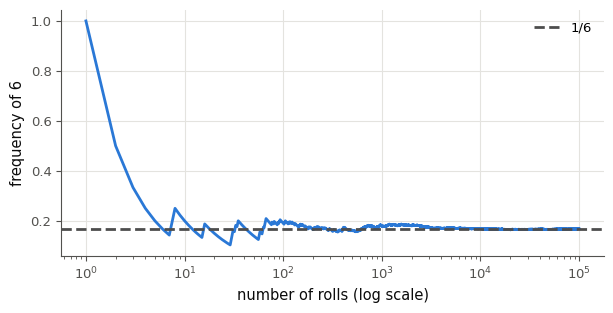

In [87]:
n = 100_000
rng = np.random.default_rng(0)
rolls = rng.integers(1, 7, size=(n, 2))
d1, d2 = rolls[:, 0], rolls[:, 1]
A, B, C = d1 % 2 == 0, d1 + d2 == 7, d1 + d2 == 8
freq_sum_7 = B.mean()
gaps = [(A & B).mean() - A.mean() * B.mean(), (A & C).mean() - A.mean() * C.mean()]
running_6 = np.cumsum(d1 == 6) / np.arange(1, n + 1)

rng2 = np.random.default_rng(1)
stds = []
for n_rolls in [100, 400, 1600, 6400]:
    freqs = (rng2.integers(1, 7, size=(200, n_rolls)) == 6).mean(axis=1)
    stds.append(freqs.std())
ratios = [round(stds[i] / stds[i + 1]) for i in range(3)]
print(freq_sum_7, np.round(gaps, 4), running_6[[99, 999, -1]], np.round(stds, 4), ratios)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.arange(1, n + 1), running_6)
ax.axhline(1 / 6, color="0.3", ls="--", label="1/6")
ax.set_xscale("log")
ax.set_xlabel("number of rolls (log scale)")
ax.set_ylabel("frequency of 6")
ax.legend()
plt.show()

In [88]:
wb.record("0B.52a", freq_sum_7, decimals=3, mistakes={"c'est la probabilité théorique : on demande la fréquence observée dans ta simulation": 1 / 6})
wb.record("0B.52b", gaps, decimals=3)
wb.record("0B.52c", [running_6[99], running_6[999], running_6[-1]], decimals=3)
wb.record("0B.52d", ratios, mistakes={"un rapport entre deux écarts-types successifs, pas entre deux variances": [round(stds[i] ** 2 / stds[i + 1] ** 2) for i in range(3)]})

WB_ANSWER {"decimals": 3, "hash": "41327e51358890abf91429da48c430f612be482a91b73570fea7edf4b023fb8b", "hash_coarse": "fa52a7cb6e5d19bf863132c371673a7080b6b06b2fa289e1b8aeeef62f3f2183", "id": "0B.52a", "kind": "float", "magnitude": -1, "mistakes": {"37cba357512ea9bb4b9d86d40b6a916b998ee8f1fd59b4d5433855b239403c90": "c'est la probabilité théorique : on demande la fréquence observée dans ta simulation"}, "sign": 1}
📝 Ex 0B.52a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "element_hashes": ["9adb28e32c07248bd1b9fe53a117aa030f00ea7312666119631672b895a63c90", "1889820240811b223b519b0f428d10d3437df8bf6af61796ac672d22a79a7709"], "hash": "c6ed7c8effb600d214d758021068a5b2f127eed08d2f9ae8fc1bd6ff583f996a", "id": "0B.52b", "kind": "array", "shape": [2]}
📝 Ex 0B.52b : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "element_hashes": ["5592d87a90441511120f62359cb30e07fde67f244c9f82f42df87bf066027473", "a95e0074b62c98f1d3db7ff9994786c8c77046bd33f3aacb2

💡 L'écart $f(A \cap B) - f(A)f(B)$ vaut environ 0,001 : du bruit de simulation, $A$ et $B$ sont indépendants. L'autre vaut environ 0,013, proche de $\frac{1}{72} \approx 0{,}014$ (0B.26) : une vraie dépendance, petite mais visible avec 100 000 lancers. Multiplier le nombre de lancers par 4 divise l'écart-type des fréquences par 2 : l'erreur décroît comme $\frac{1}{\sqrt{n}}$ (fiche §101.7.5). Pour gagner une décimale de précision, il faut 100 fois plus de lancers.

### Ex 0B.53 — Espérance et variance : le calcul exact contre la simulation 🔨 ★★ ⏱️ 20 min
**Objectif :** calculer espérance et variance d'une loi discrète, puis les retrouver par simulation.  
**Prérequis :** Ex 0B.27, Ex 0B.52 · fiche §101.7.3, §101.7.4, §101.7.5 · **Fil rouge :** synthétique · **Parcours :** R, M, C

a) et b) Écris `expectation(values, probs)` et `variance(values, probs)` (avec la formule $\mathbb{E}[X^2] - \mathbb{E}[X]^2$) pour une variable discrète donnée par deux arrays : ses valeurs et leurs probabilités. Vérifications, sur la loi de 0B.27 (`values_53`, `probs_53`) : a) $\mathbb{E}[X]$ · b) $\mathrm{Var}(X)$ · c) la variance de $3X + 2$, avec ta fonction `variance` appliquée aux valeurs transformées `3 * values_53 + 2` (2 décimales) : compare avec 0B.27 f.

Simule ensuite $n = 100\,000$ tirages, exactement ainsi : `n = 100_000`, `rng = np.random.default_rng(0)`, `x = rng.choice(values_53, size=n, p=probs_53)`, puis `y = rng.choice(values_53, size=n, p=probs_53)` (une deuxième variable de même loi, **indépendante** de la première).

d) `sample_stats` : la moyenne et la variance (`.var()`) des tirages `x` (2 décimales) ; proches de a) et b) ?
e) `var_sum_indep` : la variance de `x + y` (2 décimales) ; compare avec $\mathrm{Var}(X) + \mathrm{Var}(Y)$.
f) `var_sum_same` : la variance de `x + x` (2 décimales). Pourquoi n'est-ce plus la somme des deux variances ?

In [89]:
values_53 = np.array([0, 1, 2, 5])          # the law of 0B.27
probs_53 = np.array([0.4, 0.3, 0.2, 0.1])

In [90]:
def expectation(values, probs):
    return np.sum(values * probs)


def variance(values, probs):
    return expectation(values ** 2, probs) - expectation(values, probs) ** 2


n = 100_000
rng = np.random.default_rng(0)
x = rng.choice(values_53, size=n, p=probs_53)
y = rng.choice(values_53, size=n, p=probs_53)
sample_stats = [x.mean(), x.var()]
var_sum_indep = (x + y).var()
var_sum_same = (x + x).var()
print(expectation(values_53, probs_53), variance(values_53, probs_53), variance(3 * values_53 + 2, probs_53))
print(np.round(sample_stats, 3), round(var_sum_indep, 3), round(var_sum_same, 3))

1.2 2.16 19.44
[1.198 2.144] 4.268 8.577


In [91]:
wb.record("0B.53a", expectation(values_53, probs_53), decimals=2)
wb.record("0B.53b", variance(values_53, probs_53), decimals=2, mistakes={"Var = E[X²] − E[X]² : n'oublie pas d'élever E[X] au carré": 3.6 - 1.2})
wb.record("0B.53c", variance(3 * values_53 + 2, probs_53), decimals=2)
wb.record("0B.53d", sample_stats, decimals=2, mistakes={"ce sont les valeurs théoriques : on demande celles de la simulation": [1.2, 2.16]})
wb.record("0B.53e", var_sum_indep, decimals=2, mistakes={"c'est la valeur théorique : on demande la variance des tirages simulés": 4.32})
wb.record("0B.53f", var_sum_same, decimals=2, mistakes={"c'est la valeur théorique : on demande la variance des tirages simulés": 8.64, "x + x = 2x : ses deux termes ne sont pas indépendants, les variances ne s'additionnent plus": 4.32, "x + x = 2x : ses deux termes varient ensemble, les variances ne s'additionnent plus": 2 * x.var()})

WB_ANSWER {"decimals": 2, "hash": "ea8db0902f07c64908138462b160d1b54d908848a0099a3f2539f20b489c22d4", "hash_coarse": "d83759af6388ff3812834e605a8cdb4cd80cb211aa17b410d51fcc7a95241495", "id": "0B.53a", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 0B.53a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "0c673bf829f40528fb6e75dd99df06ffa7f480d1c3ae1669ae375db345ffc7da", "hash_coarse": "3170031ce382f23e79bae8e11ec02bc72bb01b6f4274ef9a9663b177874b9af6", "id": "0B.53b", "kind": "float", "magnitude": 0, "mistakes": {"f575b4daaaa3c4e42832338accbe375d5b633c5255182e4361466b043090c8fe": "Var = E[X²] − E[X]² : n'oublie pas d'élever E[X] au carré"}, "sign": 1}
📝 Ex 0B.53b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "502b660958662a8bf06158926793adbc3e01d9cc5119d4b61a4853f583d07181", "hash_coarse": "13375d5d0c21a12e6987c8b6ce1e9a50cd310c9585487b833b20fd2060895ecb", "id": "0B.53c", "kind": "float", "magnitude": 1, "sign": 1}
📝 Ex 0

💡 La simulation donne 1,20 et 2,14 au lieu de 1,2 et 2,16 : l'écart diminue comme $\frac{1}{\sqrt{n}}$ quand le nombre de tirages grandit. Pour des variables **indépendantes**, les variances s'additionnent ($\approx 4{,}32$ ; démontré au ch. 16). Pour $X + X = 2X$, la règle $\mathrm{Var}(aX) = a^2\,\mathrm{Var}(X)$ donne $4 \times 2{,}16 = 8{,}64$ : deux fois plus que la somme des variances, car les deux termes varient ensemble. L'espérance, elle, s'additionne toujours.

### Ex 0B.54 — L'ordre des produits : calculer A·B·C·v des dizaines de fois plus vite 🏆 ★★★ ⏱️ 40 min
**Objectif :** choisir l'ordre des produits matriciels qui minimise le nombre de multiplications, et mesurer le gain.  
**Prérequis :** Ex 0B.30, Ex 0B.46 · fiche §101.4.3, §101.1.1 · **Fil rouge :** synthétique · **Parcours :** M, C

🏆 **Objectif** : calculer $\mathbf{A}\mathbf{B}\mathbf{C}\mathbf{v}$ ($\mathbf{A}$, $\mathbf{B}$, $\mathbf{C}$ de taille $1000 \times 1000$, $\mathbf{v}$ de dimension 1000) **au moins 20 fois plus vite** que de gauche à droite, avec le même résultat. (En `FAST_MODE = False`, les matrices font $2000 \times 2000$.)

a) Écris `left_to_right(A, B, C, v)`, qui calcule $((\mathbf{A}\mathbf{B})\mathbf{C})\mathbf{v}$, et `right_to_left(A, B, C, v)`, qui calcule $\mathbf{A}(\mathbf{B}(\mathbf{C}\mathbf{v}))$, avec `@`. Vérification a) : les deux résultats sont-ils égaux (`np.allclose`) ?

b) Écris `matmul_cost(shape_a, shape_b)` : le nombre de multiplications d'un produit $(m, n) \times (n, p)$, soit $m\,n\,p$ ; un vecteur de forme `(n,)` compte comme une matrice $(n, 1)$. Puis `chain_costs(n)`, qui renvoie `[coût de gauche à droite, coût de droite à gauche]` pour des matrices $n \times n$ et un vecteur de dimension $n$ : additionne les coûts des trois produits de chaque ordre, en suivant les formes des résultats intermédiaires. Vérification b) : `chain_costs(1000)` (compare avec 0B.30).

c) La cellule de vérification mesure les deux temps (le meilleur de 3 essais) et calcule `speedup` = temps de gauche à droite / temps de droite à gauche. 🏆 Objectif atteint si `speedup >= 20`.

d) Dans ta copie : le gain en temps est-il aussi grand que le gain en nombre de multiplications ? Pourquoi ? (Indice : un produit matrice-vecteur lit toute la matrice en mémoire pour très peu de calcul, alors qu'un produit matriciel réutilise chaque nombre lu des centaines de fois.)

e) Bonus : un réseau de trois couches **linéaires** (sans fonction d'activation) calcule $\mathbf{X}\mathbf{W}_1\mathbf{W}_2\mathbf{W}_3$, avec $\mathbf{X}$ de forme $(64, 784)$ (un mini-lot d'images MNIST), $\mathbf{W}_1$ $(784, 512)$, $\mathbf{W}_2$ $(512, 512)$ et $\mathbf{W}_3$ $(512, 10)$. `network_costs` : la liste `[coût de gauche à droite, coût de X(W1(W2 W3))]`, avec `matmul_cost`. Dans ta copie : pourquoi ce regroupement n'est-il plus possible dès qu'une fonction d'activation s'intercale entre les couches (ch. 16 et 17) ?

In [92]:
rng_54 = np.random.default_rng(0)
N54 = 1000 if FAST_MODE else 2000
A54, B54, C54 = (rng_54.normal(size=(N54, N54)) for _ in range(3))
v54 = rng_54.normal(size=N54)

In [93]:
def left_to_right(A, B, C, v):
    return ((A @ B) @ C) @ v


def right_to_left(A, B, C, v):
    return A @ (B @ (C @ v))


def matmul_cost(shape_a, shape_b):
    """Number of multiplications of a (m, n) x (n, p) product; a vector (n,) counts as (n, 1)."""
    m, n = shape_a if len(shape_a) == 2 else (shape_a[0], 1)
    n_b, p = shape_b if len(shape_b) == 2 else (shape_b[0], 1)
    if n != n_b:
        raise ValueError(f"cannot multiply {shape_a} by {shape_b}")
    return m * n * p


def chain_costs(n):
    """[cost of ((AB)C)v, cost of A(B(Cv))] for n x n matrices and a vector of dimension n."""
    square, vector = (n, n), (n,)
    left = matmul_cost(square, square) + matmul_cost(square, square) + matmul_cost(square, vector)
    right = 3 * matmul_cost(square, vector)
    return [left, right]


X_shape, W1_shape, W2_shape, W3_shape = (64, 784), (784, 512), (512, 512), (512, 10)
network_costs = [matmul_cost(X_shape, W1_shape) + matmul_cost((64, 512), W2_shape) + matmul_cost((64, 512), W3_shape),
                 matmul_cost(W2_shape, W3_shape) + matmul_cost(W1_shape, (512, 10)) + matmul_cost(X_shape, (784, 10))]

same = np.allclose(left_to_right(A54, B54, C54, v54), right_to_left(A54, B54, C54, v54))
t_left = measure(left_to_right, A54, B54, C54, v54)
t_right = measure(right_to_left, A54, B54, C54, v54)
speedup = t_left / t_right
costs = chain_costs(1000)
print(same, costs, costs[0] / costs[1], network_costs, network_costs[0] / network_costs[1])
print(f"left to right: {t_left * 1000:.1f} ms, right to left: {t_right * 1000:.2f} ms, speedup: {speedup:.0f}")

True [2001000000, 3000000] 667.0 [42795008, 7137280] 5.995982783357245
left to right: 33.5 ms, right to left: 0.66 ms, speedup: 51


In [94]:
wb.record("0B.54a", bool(same))
wb.record("0B.54b", costs, mistakes={"de droite à gauche, chaque résultat intermédiaire est un vecteur : quel est le coût d'un produit matrice-vecteur ?": [2_001_000_000, 3_000_000_000]})
wb.record("0B.54e", network_costs)

WB_ANSWER {"hash": "a9d03d74aefd4d9aee9da208daa90af7477f22ff8622aa310bd7f9d9f8346732", "id": "0B.54a", "kind": "bool"}
📝 Ex 0B.54a : réponse enregistrée (bool).
WB_ANSWER {"decimals": 0, "element_hashes": ["1976a308c3baf4b05700cf017fabcb8d1f8dae6e915a8355186afbcd613ef331", "7b9e04abe73c33a64630a67d36098594fc6aa1d31729e35c8958851f414c44ed"], "hash": "c5ee564d12d01bc47ab0babfbdb2110f905243c2e1a03b8d7a24f86230ec7d40", "id": "0B.54b", "integer": true, "kind": "array", "mistakes": {"924943bfa3a7183de9a6da64c88a51ca3a2df76976756aceddc43779e8e6d0a6": "de droite à gauche, chaque résultat intermédiaire est un vecteur : quel est le coût d'un produit matrice-vecteur ?"}, "shape": [2]}
📝 Ex 0B.54b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["73b366bccaf3786ffce40fa96a651d993b7ff9793e3eaa8db2fd2c2368c5cd4b", "2585eff699bb4715b6b77427bf5a40c7db2af0e579ba170d2c3e1f40d05d3b77"], "hash": "7637b61ff0252ca1cbf8193240ae49adb4d5372feb0902faf6085d5eee953668", "

💡 Le calcul de droite à gauche fait environ 670 fois moins de multiplications, mais n'est « que » 30 à 100 fois plus rapide selon la machine : un produit matrice-vecteur est limité par la vitesse de la mémoire (chaque nombre lu ne sert qu'une fois), alors qu'un produit matriciel réutilise chaque nombre et exploite à fond le processeur. En e, regrouper les poids divise le coût par 6 : un réseau linéaire équivaut à **une seule** matrice $\mathbf{W}_1\mathbf{W}_2\mathbf{W}_3$, ce qui montre qu'empiler des couches linéaires n'apporte rien. Dès qu'une activation non linéaire s'intercale, $f(\mathbf{X}\mathbf{W}_1)\mathbf{W}_2 \neq \mathbf{X}(\mathbf{W}_1\mathbf{W}_2)$ : on ne peut plus regrouper, et c'est justement ce qui donne sa puissance au réseau (ch. 16 et 17). La rétropropagation applique l'idée de a à c : partir d'un nombre (la loss) et n'enchaîner que des produits vecteur-matrice (ch. 18).

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu vérifier qu'un produit matriciel existe et donner sa forme, sans calculer, puis l'écrire en Python pur et avec `@` ?
2. Sais-tu vérifier une dérivée calculée à la main avec une pente centrée, et dériver une composition avec la règle de la chaîne ?
3. Sais-tu calculer une espérance et une variance à partir d'un tableau de probabilités, et les retrouver par simulation ?

**Pour aller plus loin** : la série vidéo *Essence of linear algebra* de 3Blue1Brown (les matrices vues comme des transformations du plan) et le livre libre *Mathematics for Machine Learning* (Deisenroth, Faisal et Ong), cités dans la fiche. La suite : le ch. 2 (statistiques) réutilise la moyenne, la variance et la simulation ; le ch. 5, les dérivées et le gradient ; `linalg_basics` t'aidera à lire ce que font les couches des ch. 16 à 18.